In [2]:
# ==========================================
# CELL 1
# LOAD ALL PARTICIPANT FILES
# ==========================================

import pandas as pd
import numpy as np
import glob
import os
import re

# ==========================================
# PATH
# ==========================================

folder_path = "../Data/stresstest1_train"

# ==========================================
# FIND ALL CSV FILES
# ==========================================

csv_files = sorted(
    glob.glob(
        os.path.join(folder_path, "*.csv")
    )
)

print("=================================")
print("FOUND FILES")
print("=================================")

for file in csv_files:
    print(file)

# ==========================================
# LOAD FILES
# ==========================================

all_dataframes = []

for file in csv_files:

    # --------------------------------------
    # LOAD CSV
    # --------------------------------------

    df = pd.read_csv(
        file,
        sep=';'
    )

    # --------------------------------------
    # EXTRACT PARTICIPANT ID
    # --------------------------------------

    filename = os.path.basename(file)

    match = re.search(r'(\d+)', filename)

    participant_id = int(match.group(1))

    # --------------------------------------
    # ADD PARTICIPANT COLUMN
    # --------------------------------------

    df["Participant"] = participant_id

    # --------------------------------------
    # APPEND
    # --------------------------------------

    all_dataframes.append(df)

# ==========================================
# COMBINE ALL PARTICIPANTS
# ==========================================

combined_df = pd.concat(
    all_dataframes,
    ignore_index=True
)

# ==========================================
# SHOW INFO
# ==========================================

print("\n=================================")
print("COMBINED DATAFRAME")
print("=================================")

print(combined_df.head())

print("\nShape:")
print(combined_df.shape)

print("\nParticipants:")
print(
    sorted(
        combined_df["Participant"].unique()
    )
)

FOUND FILES
../Data/stresstest1_train\training_data1.csv
../Data/stresstest1_train\training_data2.csv
../Data/stresstest1_train\training_data3.csv
../Data/stresstest1_train\training_data4.csv
../Data/stresstest1_train\training_data5.csv
../Data/stresstest1_train\training_data6.csv
../Data/stresstest1_train\training_data7.csv
../Data/stresstest1_train\training_data8.csv

COMBINED DATAFRAME
          HR              RMSSD     SC_PH     SC_RR  Experiment_Phase  \
0  57.095142  74.40946960449219  1.416533  0.033333                 0   
1  57.471355  74.88995361328125   1.81162  0.050000                 0   
2  58.960678  78.67300415039062  2.796309  0.066667                 0   
3   60.72472   82.7143325805664   2.96458  0.133333                 0   
4  61.632771  88.30150604248047  2.567946  0.100000                 0   

   baseline_classification  ground_truth  Num_of_classifications  Participant  \
0                        0             0                    95.0            1   
1      

In [3]:
# ==========================================
# CELL 2
# CLEAN AND PREPARE DATA
# ==========================================

# ==========================================
# FEATURES
# ==========================================

features = [
    "HR",
    "RMSSD",
    "SC_PH",
    "SC_RR"
]

# ==========================================
# CONVERT TO NUMERIC
# ==========================================

for feature in features:

    combined_df[feature] = pd.to_numeric(
        combined_df[feature],
        errors="coerce"
    )

# ==========================================
# INVALID VALUES
# ==========================================

print("=================================")
print("INVALID VALUES")
print("=================================")

for feature in features:

    invalid_count = (
        combined_df[feature]
        .isna()
        .sum()
    )

    print(
        f"{feature}: "
        f"{invalid_count}"
    )

INVALID VALUES
HR: 1
RMSSD: 1
SC_PH: 1
SC_RR: 0


In [4]:
# ==========================================
# CELL 3
# SETTINGS
# ==========================================

classification_col = "baseline_classification"
# classification_col = "improved_classification"

features = [
    "HR",
    "RMSSD",
    "SC_PH",
    "SC_RR"
]

# ==========================================
# PHASE GROUPS
# ==========================================

rest_phases = [2,4,6,8,10,12]

stroop_phases = [1,3,5]

mat_phases = [7,9,11]

print("Settings loaded.")

Settings loaded.


In [5]:
# ==========================================
# CELL 4
# CREATE COMPLETE SUMMARY DATAFRAME
# ==========================================

summary_rows = []

participants = sorted(
    combined_df["Participant"].unique()
)

# ==========================================
# LOOP PARTICIPANTS
# ==========================================

for participant in participants:

    participant_df = combined_df[
        combined_df["Participant"] == participant
    ]

    row = {}

    # ======================================
    # BASIC INFO
    # ======================================

    row["Participant"] = participant

    # ======================================
    # PHASE ANALYSIS FUNCTION
    # ======================================

    def add_phase_statistics(
        dataframe,
        phases,
        prefix
    ):

        phase_df = dataframe[
            dataframe["Experiment_Phase"]
            .isin(phases)
        ]

        total = len(phase_df)

        row[f"{prefix}_Total"] = total

        for c in [0,1,2]:

            count = (
                phase_df[classification_col] == c
            ).sum()

            percentage = (
                (count / total) * 100
                if total > 0 else 0
            )

            row[f"{prefix}_Class{c}_Count"] = count

            row[f"{prefix}_Class{c}_Percent"] = percentage

    # ======================================
    # PHASE ANALYSIS
    # ======================================

    add_phase_statistics(
        participant_df,
        rest_phases,
        "REST"
    )

    add_phase_statistics(
        participant_df,
        stroop_phases,
        "STROOP"
    )

    add_phase_statistics(
        participant_df,
        mat_phases,
        "MAT"
    )

    # ======================================
    # BASELINE (PHASE 0)
    # ======================================

    baseline_df = participant_df[
        participant_df["Experiment_Phase"] == 0
    ]

    row["Baseline_Total"] = len(
        baseline_df
    )

    for feature in features:

        row[f"Baseline_{feature}"] = (
            baseline_df[feature].mean()
        )

    # ======================================
    # CLASS ANALYSIS
    # ======================================

    for c in [0,1,2]:

        class_df = participant_df[
            participant_df[classification_col] == c
        ]

        row[f"Class{c}_Total"] = len(
            class_df
        )

        for feature in features:

            row[f"Class{c}_{feature}"] = (
                class_df[feature].mean()
            )

    # ======================================
    # TOTAL DATASET
    # ======================================

    row["Dataset_Total"] = len(
        participant_df
    )

    for feature in features:

        row[f"Dataset_{feature}"] = (
            participant_df[feature].mean()
        )

    # ======================================
    # SAVE ROW
    # ======================================

    summary_rows.append(row)

# ==========================================
# CREATE SUMMARY DATAFRAME
# ==========================================

summary_df = pd.DataFrame(
    summary_rows
)

# ==========================================
# SHOW RESULT
# ==========================================

print("=================================")
print("SUMMARY DATAFRAME")
print("=================================")

print(summary_df.head())

SUMMARY DATAFRAME
   Participant  REST_Total  REST_Class0_Count  REST_Class0_Percent  \
0            1          56                 46            82.142857   
1            2          74                 36            48.648649   
2            3          57                 56            98.245614   
3            4          59                 32            54.237288   
4            5          53                  5             9.433962   

   REST_Class1_Count  REST_Class1_Percent  REST_Class2_Count  \
0                 10            17.857143                  0   
1                 37            50.000000                  1   
2                  1             1.754386                  0   
3                 23            38.983051                  4   
4                 39            73.584906                  9   

   REST_Class2_Percent  STROOP_Total  STROOP_Class0_Count  ...  Class2_Total  \
0             0.000000            28                   15  ...             0   
1             1.

In [7]:
# ==========================================
# CELL 5
# SAVE SUMMARY CSV
# ==========================================

save_path = "../data/Results/participant_summary_test1.csv"

summary_df.to_csv(
    save_path,
    index=False
)

print("Saved:")
print(save_path)

Saved:
../data/Results/participant_summary_test1.csv


In [8]:
# ==========================================
# CELL 6
# QUICK OVERVIEW
# ==========================================

pd.set_option(
    'display.max_columns',
    None
)

summary_df

,Participant,REST_Total,REST_Class0_Count,REST_Class0_Percent,REST_Class1_Count,REST_Class1_Percent,REST_Class2_Count,REST_Class2_Percent,STROOP_Total,STROOP_Class0_Count,STROOP_Class0_Percent,STROOP_Class1_Count,STROOP_Class1_Percent,STROOP_Class2_Count,STROOP_Class2_Percent,MAT_Total,MAT_Class0_Count,MAT_Class0_Percent,MAT_Class1_Count,MAT_Class1_Percent,MAT_Class2_Count,MAT_Class2_Percent,Baseline_Total,Baseline_HR,Baseline_RMSSD,Baseline_SC_PH,Baseline_SC_RR,Class0_Total,Class0_HR,Class0_RMSSD,Class0_SC_PH,Class0_SC_RR,Class1_Total,Class1_HR,Class1_RMSSD,Class1_SC_PH,Class1_SC_RR,Class2_Total,Class2_HR,Class2_RMSSD,Class2_SC_PH,Class2_SC_RR,Dataset_Total,Dataset_HR,Dataset_RMSSD,Dataset_SC_PH,Dataset_SC_RR
0,1,56,46,82.142857,10,17.857143,0,0.000000,28,15,53.571429,13,46.428571,0,0.000000,27,21,77.777778,6,22.222222,0,0.000000,23,58.620449,71.660716,2.242024,0.072464,98,59.843370,66.944635,1.606136,0.033673,36,60.059914,63.070408,2.841611,0.120833,0,NaN,NaN,NaN,NaN,134,59.901546,65.895972,1.938054,0.057090
1,2,74,36,48.648649,37,50.000000,1,1.351351,28,13,46.428571,15,53.571429,0,0.000000,26,10,38.461538,16,61.538462,0,0.000000,23,77.710873,68.796953,1.981619,0.090580,76,73.017946,73.686233,2.164597,0.068202,73,72.465690,68.395403,3.336765,0.103653,2,74.794834,81.505726,3.525080,0.325000,151,72.774496,71.231984,2.749294,0.088742
2,3,57,56,98.245614,1,1.754386,0,0.000000,27,17,62.962963,2,7.407407,8,29.629630,28,25,89.285714,1,3.571429,2,7.142857,24,77.736099,56.836661,0.221206,0.000000,122,77.694656,56.991571,0.699701,0.005055,4,66.105429,49.288220,2.021014,0.054167,10,90.160822,40.834830,1.804895,0.081667,136,78.270426,55.577006,0.819828,0.012132
3,4,59,32,54.237288,23,38.983051,4,6.779661,29,5,17.241379,14,48.275862,10,34.482759,30,18,60.000000,10,33.333333,1,3.333333,24,70.434532,67.417803,0.809306,0.013194,79,68.604835,65.562536,1.280158,0.020042,47,69.555334,61.867597,3.344259,0.104610,15,90.088086,45.197585,2.457314,0.113333,142,71.094559,62.037189,2.087836,0.058333
4,5,53,5,9.433962,39,73.584906,9,16.981132,28,0,0.000000,16,57.142857,8,28.571429,29,0,0.000000,14,48.275862,13,44.827586,22,88.166605,28.313360,2.544023,0.061364,6,80.953948,39.734977,1.298914,0.011111,79,91.337003,29.874134,3.661868,0.075527,41,94.811993,23.636854,2.253816,0.060163,132,92.814467,27.027102,3.071332,0.066667
5,6,55,55,100.000000,0,0.000000,0,0.000000,28,28,100.000000,0,0.000000,0,0.000000,28,28,100.000000,0,0.000000,0,0.000000,24,81.416571,55.500165,0.002459,0.000000,134,85.337006,44.822161,0.001662,0.000000,0,NaN,NaN,NaN,NaN,1,106.132568,47.696270,0.006751,0.000000,135,85.492197,44.843450,0.001699,0.000000
6,7,55,55,100.000000,0,0.000000,0,0.000000,27,27,100.000000,0,0.000000,0,0.000000,26,26,100.000000,0,0.000000,0,0.000000,23,85.449474,43.708109,0.896398,0.042029,128,76.794335,46.366929,0.540371,0.000521,2,90.573673,36.155010,5.077561,0.241667,1,89.781960,39.158401,4.509175,0.466667,131,77.103849,46.155995,0.639937,0.007761
7,8,57,48,84.210526,8,14.035088,1,1.754386,27,21,77.777778,6,22.222222,0,0.000000,27,23,85.185185,4,14.814815,0,0.000000,23,69.126975,36.022537,0.632822,0.002899,114,67.033002,40.256896,0.960474,0.010965,19,67.799608,43.614516,2.388029,0.078947,1,63.538284,44.689270,2.224556,0.133333,134,67.115620,40.766054,1.172322,0.021517


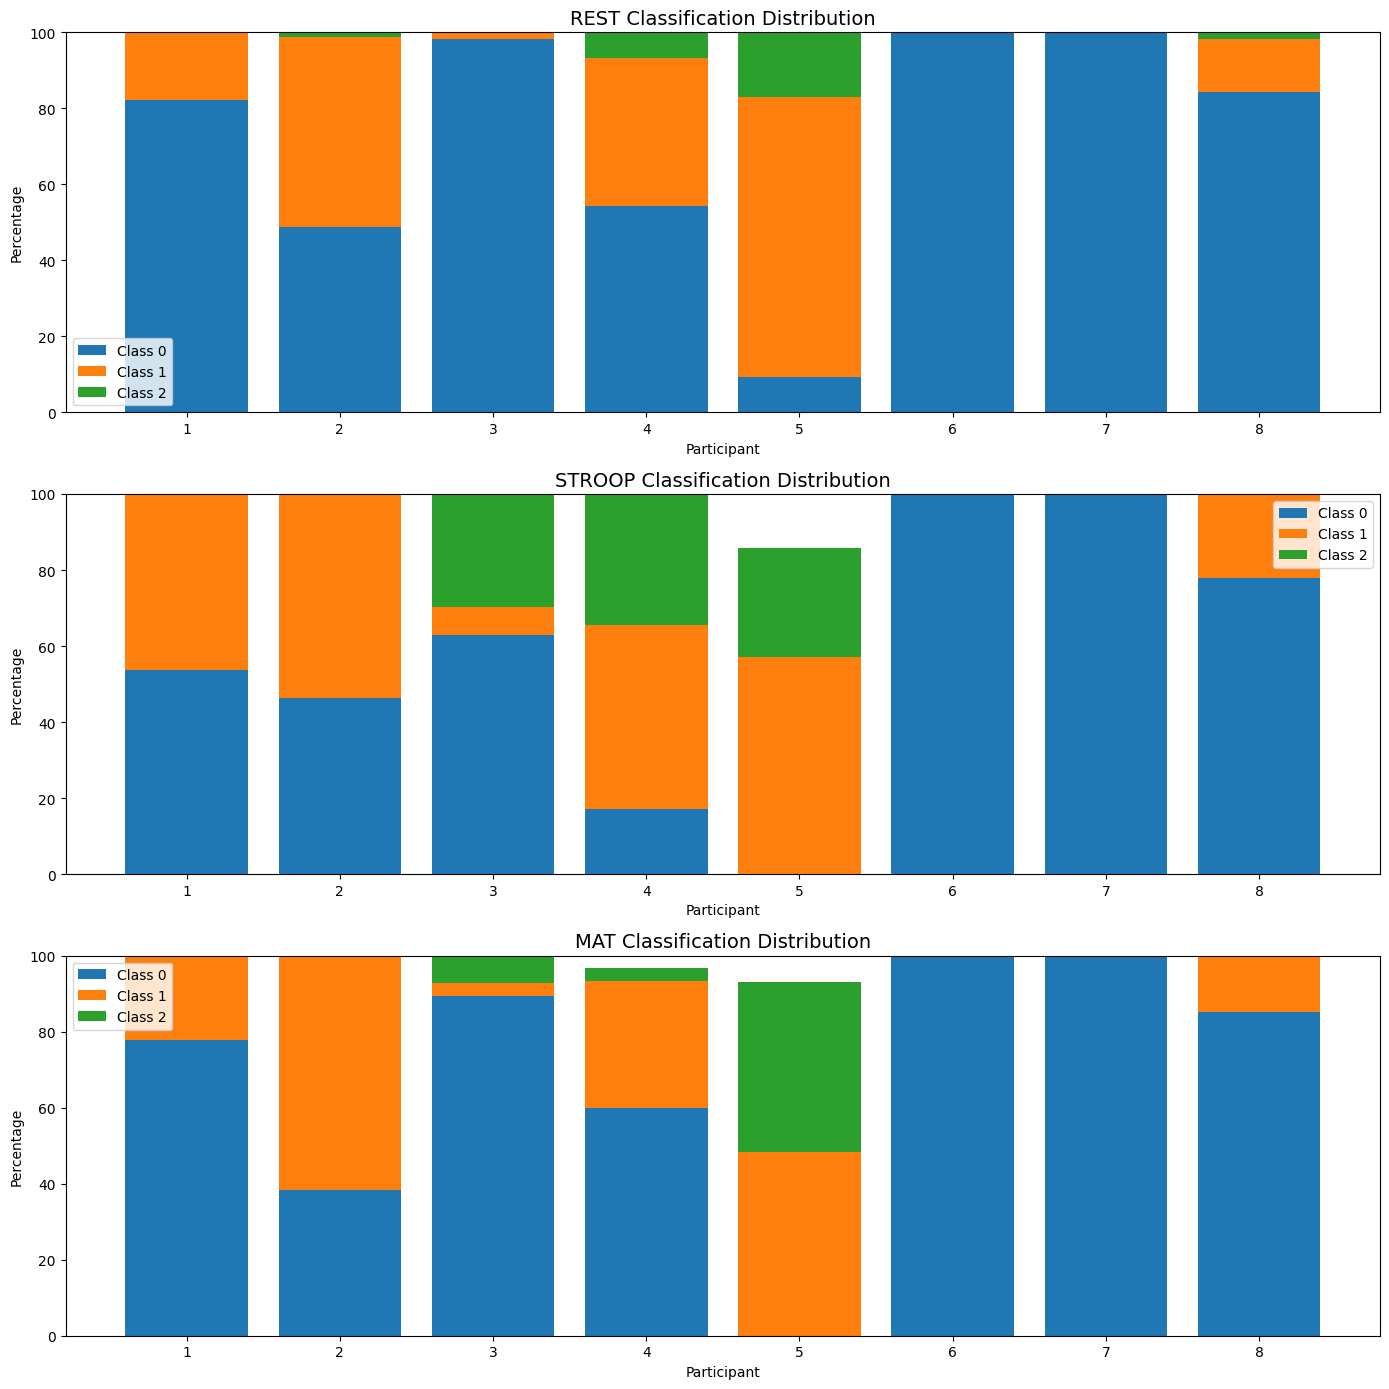

In [9]:
# ==========================================
# CELL 7
# STACKED BARPLOT
# PHASE CLASSIFICATION DISTRIBUTION
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# PARTICIPANTS
# ==========================================

participants = summary_df["Participant"]

# ==========================================
# CREATE FIGURE
# ==========================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 14)
)

phase_info = [
    ("REST", axes[0]),
    ("STROOP", axes[1]),
    ("MAT", axes[2])
]

# ==========================================
# PLOT EACH PHASE
# ==========================================

for phase_name, ax in phase_info:

    class0 = summary_df[
        f"{phase_name}_Class0_Percent"
    ]

    class1 = summary_df[
        f"{phase_name}_Class1_Percent"
    ]

    class2 = summary_df[
        f"{phase_name}_Class2_Percent"
    ]

    # --------------------------------------
    # STACKED BARS
    # --------------------------------------

    ax.bar(
        participants,
        class0,
        label="Class 0"
    )

    ax.bar(
        participants,
        class1,
        bottom=class0,
        label="Class 1"
    )

    ax.bar(
        participants,
        class2,
        bottom=class0 + class1,
        label="Class 2"
    )

    # --------------------------------------
    # STYLE
    # --------------------------------------

    ax.set_title(
        f"{phase_name} Classification Distribution",
        fontsize=14
    )

    ax.set_xlabel(
        "Participant"
    )

    ax.set_ylabel(
        "Percentage"
    )

    ax.set_ylim(0, 100)

    ax.legend()

# ==========================================
# LAYOUT
# ==========================================

plt.tight_layout()

plt.show()

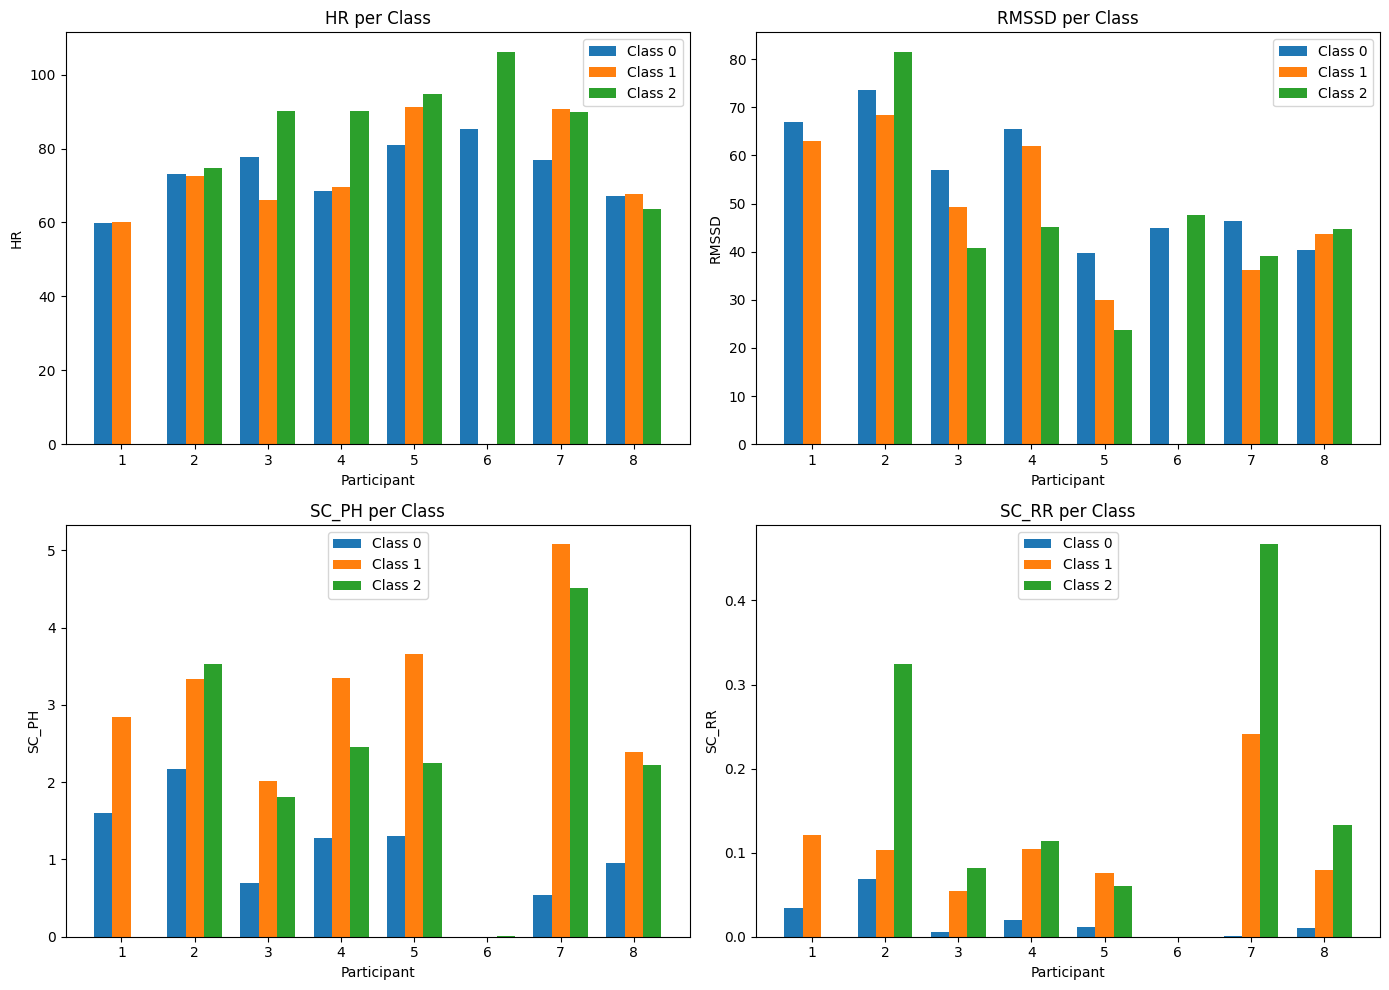

In [10]:
# ==========================================
# CELL 8
# PHYSIOLOGICAL CLASS PROFILES
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# FEATURES
# ==========================================

features = [
    "HR",
    "RMSSD",
    "SC_PH",
    "SC_RR"
]

# ==========================================
# CREATE FIGURE
# ==========================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)

axes = axes.flatten()

# ==========================================
# PLOT EACH FEATURE
# ==========================================

for i, feature in enumerate(features):

    ax = axes[i]

    class0 = summary_df[f"Class0_{feature}"]
    class1 = summary_df[f"Class1_{feature}"]
    class2 = summary_df[f"Class2_{feature}"]

    x = np.arange(len(summary_df))

    width = 0.25

    # --------------------------------------
    # BARS
    # --------------------------------------

    ax.bar(
        x - width,
        class0,
        width,
        label="Class 0"
    )

    ax.bar(
        x,
        class1,
        width,
        label="Class 1"
    )

    ax.bar(
        x + width,
        class2,
        width,
        label="Class 2"
    )

    # --------------------------------------
    # STYLE
    # --------------------------------------

    ax.set_title(
        f"{feature} per Class"
    )

    ax.set_xlabel(
        "Participant"
    )

    ax.set_ylabel(
        feature
    )

    ax.set_xticks(x)

    ax.set_xticklabels(
        summary_df["Participant"]
    )

    ax.legend()

# ==========================================
# LAYOUT
# ==========================================

plt.tight_layout()

plt.show()

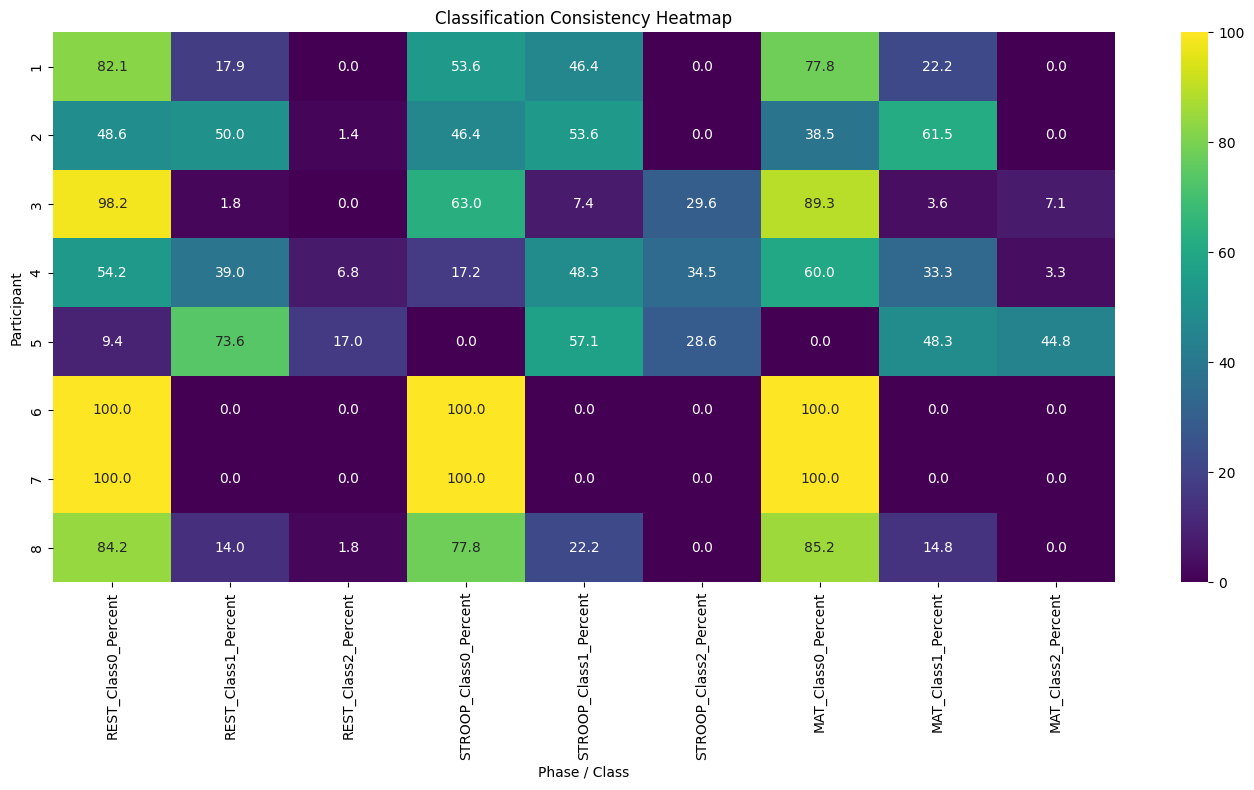

In [11]:
# ==========================================
# CELL 9
# PARTICIPANT CONSISTENCY HEATMAP
# ==========================================

import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# SELECT COLUMNS
# ==========================================

heatmap_df = summary_df[[
    "Participant",

    "REST_Class0_Percent",
    "REST_Class1_Percent",
    "REST_Class2_Percent",

    "STROOP_Class0_Percent",
    "STROOP_Class1_Percent",
    "STROOP_Class2_Percent",

    "MAT_Class0_Percent",
    "MAT_Class1_Percent",
    "MAT_Class2_Percent"
]]

# ==========================================
# SET INDEX
# ==========================================

heatmap_df = heatmap_df.set_index(
    "Participant"
)

# ==========================================
# PLOT
# ==========================================

plt.figure(figsize=(14,8))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".1f",
    cmap="viridis"
)

# ==========================================
# STYLE
# ==========================================

plt.title(
    "Classification Consistency Heatmap"
)

plt.ylabel(
    "Participant"
)

plt.xlabel(
    "Phase / Class"
)

plt.tight_layout()

plt.show()

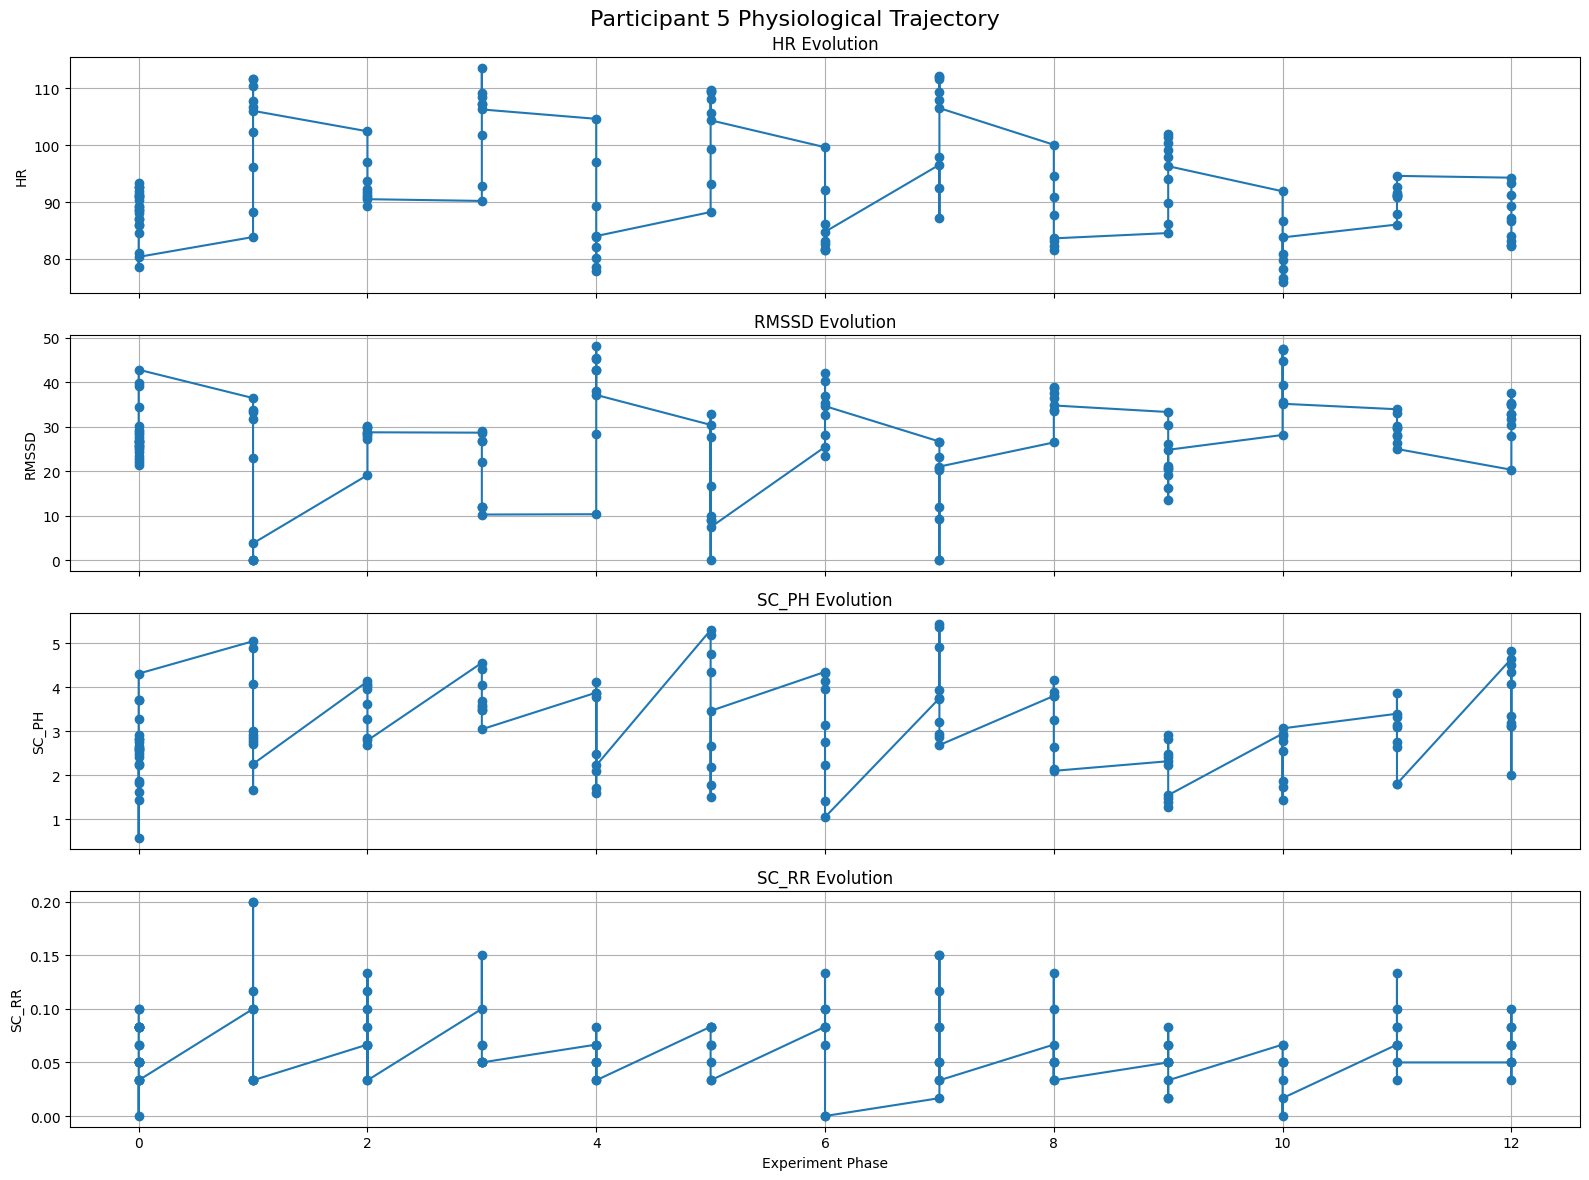

In [13]:
# ==========================================
# CELL 10
# TRAJECTORY ANALYSIS
# FEATURE EVOLUTION THROUGH PHASES
# ==========================================

import matplotlib.pyplot as plt

# ==========================================
# PARTICIPANT SELECTION
# ==========================================

participant_id = 5

participant_df = combined_df[
    combined_df["Participant"] == participant_id
]

# ==========================================
# FEATURES
# ==========================================

features = [
    "HR",
    "RMSSD",
    "SC_PH",
    "SC_RR"
]

# ==========================================
# CREATE FIGURE
# ==========================================

fig, axes = plt.subplots(
    4,
    1,
    figsize=(16, 12),
    sharex=True
)

# ==========================================
# PLOT FEATURES
# ==========================================

for i, feature in enumerate(features):

    ax = axes[i]

    ax.plot(
        participant_df["Experiment_Phase"],
        participant_df[feature],
        marker='o'
    )

    # --------------------------------------
    # STYLE
    # --------------------------------------

    ax.set_title(
        f"{feature} Evolution"
    )

    ax.set_ylabel(
        feature
    )

    ax.grid(True)

# ==========================================
# FINAL STYLE
# ==========================================

axes[-1].set_xlabel(
    "Experiment Phase"
)

plt.suptitle(
    f"Participant {participant_id} Physiological Trajectory",
    fontsize=16
)

plt.tight_layout()

plt.show()

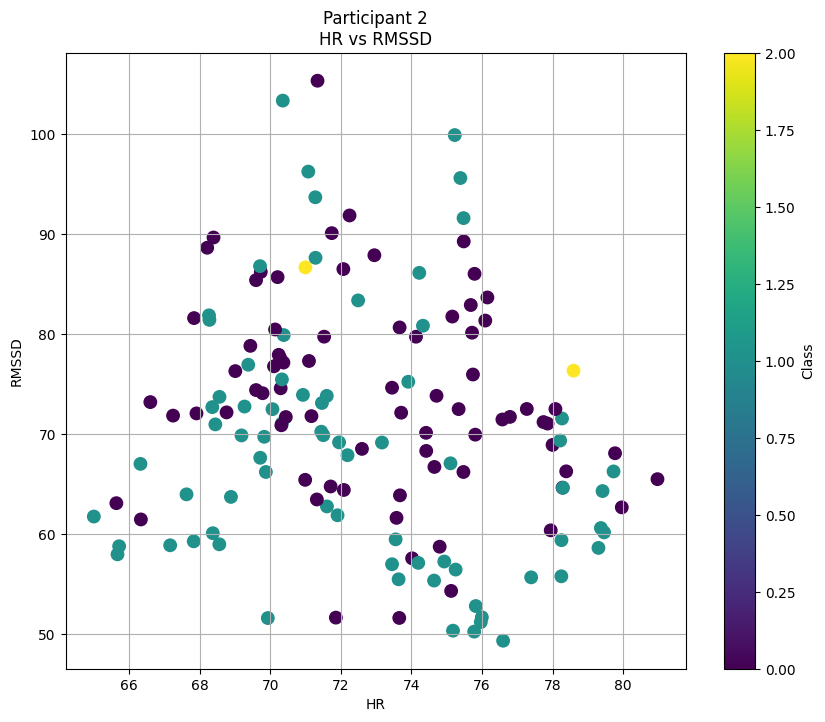

In [14]:
# ==========================================
# CELL 11
# HR vs RMSSD SCATTER
# COLOR = CLASS
# ==========================================

import matplotlib.pyplot as plt

# ==========================================
# PARTICIPANT
# ==========================================

participant_id = 2

participant_df = combined_df[
    combined_df["Participant"] == participant_id
]

# ==========================================
# PLOT
# ==========================================

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    participant_df["HR"],
    participant_df["RMSSD"],
    c=participant_df[classification_col],
    s=80
)

# ==========================================
# STYLE
# ==========================================

plt.xlabel("HR")

plt.ylabel("RMSSD")

plt.title(
    f"Participant {participant_id}\nHR vs RMSSD"
)

plt.grid(True)

plt.colorbar(
    scatter,
    label="Class"
)

plt.show()

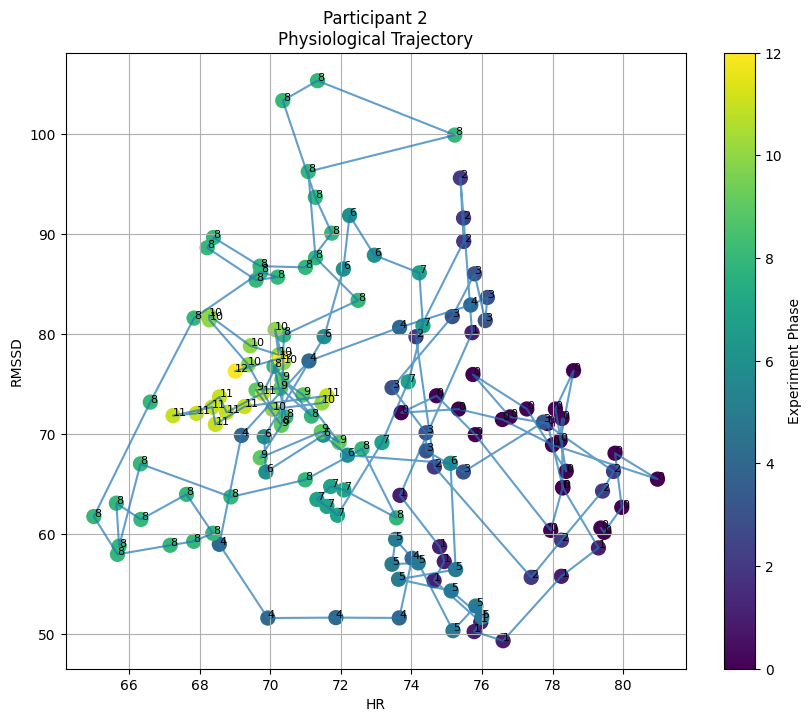

In [15]:
# ==========================================
# CELL 12
# HR/RMSSD TRAJECTORY
# ==========================================

import matplotlib.pyplot as plt

participant_id = 2

participant_df = combined_df[
    combined_df["Participant"] == participant_id
]

# ==========================================
# PLOT
# ==========================================

plt.figure(figsize=(10,8))

# --------------------------------------
# TRAJECTORY LINE
# --------------------------------------

plt.plot(
    participant_df["HR"],
    participant_df["RMSSD"],
    alpha=0.7
)

# --------------------------------------
# PHASE POINTS
# --------------------------------------

scatter = plt.scatter(
    participant_df["HR"],
    participant_df["RMSSD"],
    c=participant_df["Experiment_Phase"],
    s=100
)

# ==========================================
# LABEL PHASES
# ==========================================

for i, row in participant_df.iterrows():

    plt.text(
        row["HR"],
        row["RMSSD"],
        str(int(row["Experiment_Phase"])),
        fontsize=8
    )

# ==========================================
# STYLE
# ==========================================

plt.xlabel("HR")

plt.ylabel("RMSSD")

plt.title(
    f"Participant {participant_id}\nPhysiological Trajectory"
)

plt.grid(True)

plt.colorbar(
    scatter,
    label="Experiment Phase"
)

plt.show()

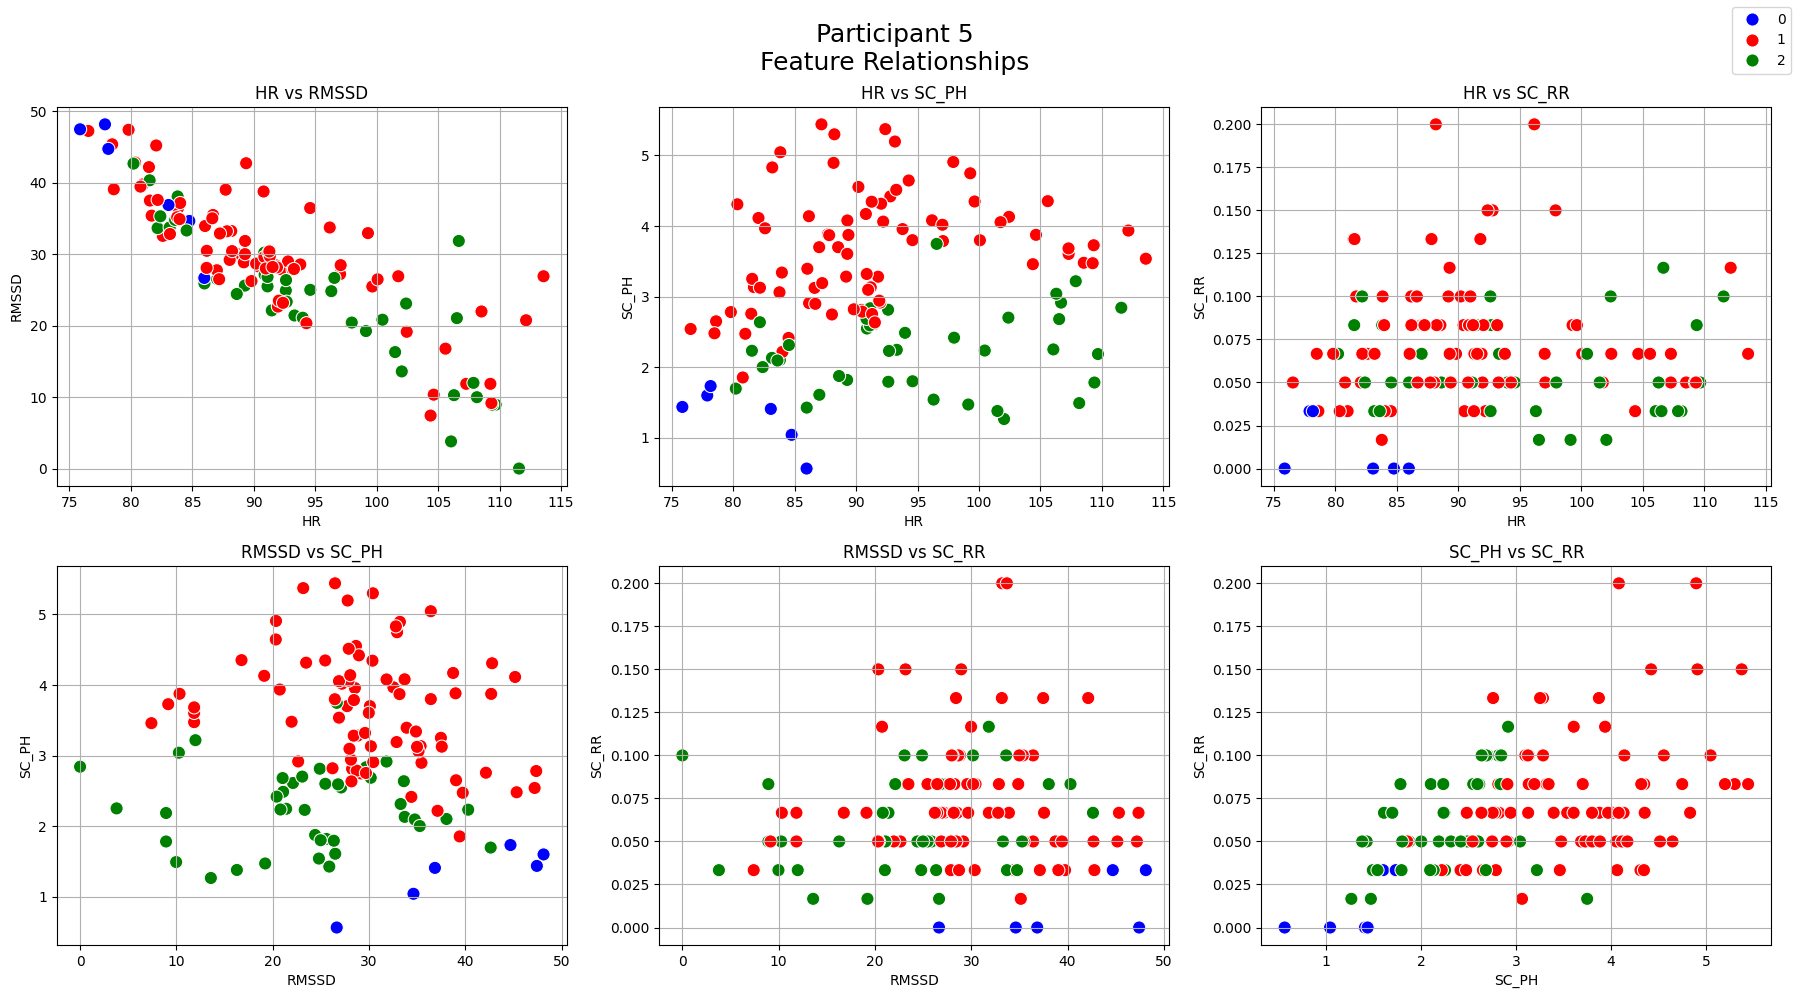

In [22]:
# ==========================================
# CELL 13B
# IMPROVED FEATURE RELATIONSHIPS
# ==========================================

import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# PARTICIPANT
# ==========================================

participant_id = 5

participant_df = combined_df[
    combined_df["Participant"] == participant_id
].copy()

# ==========================================
# REMOVE INVALID CLASS
# ==========================================

participant_df = participant_df[
    participant_df[classification_col] != 255
]

# ==========================================
# COLORS
# ==========================================

palette = {
    0: "blue",
    1: "red",
    2: "green"
}

# ==========================================
# CREATE FIGURE
# ==========================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18,10)
)

# ==========================================
# HR vs RMSSD
# ==========================================

sns.scatterplot(
    data=participant_df,
    x="HR",
    y="RMSSD",
    hue=classification_col,
    palette=palette,
    s=90,
    ax=axes[0,0]
)

axes[0,0].set_title(
    "HR vs RMSSD"
)

# ==========================================
# HR vs SC_PH
# ==========================================

sns.scatterplot(
    data=participant_df,
    x="HR",
    y="SC_PH",
    hue=classification_col,
    palette=palette,
    s=90,
    ax=axes[0,1]
)

axes[0,1].set_title(
    "HR vs SC_PH"
)

# ==========================================
# HR vs SC_RR
# ==========================================

sns.scatterplot(
    data=participant_df,
    x="HR",
    y="SC_RR",
    hue=classification_col,
    palette=palette,
    s=90,
    ax=axes[0,2]
)

axes[0,2].set_title(
    "HR vs SC_RR"
)

# ==========================================
# RMSSD vs SC_PH
# ==========================================

sns.scatterplot(
    data=participant_df,
    x="RMSSD",
    y="SC_PH",
    hue=classification_col,
    palette=palette,
    s=90,
    ax=axes[1,0]
)

axes[1,0].set_title(
    "RMSSD vs SC_PH"
)

# ==========================================
# RMSSD vs SC_RR
# ==========================================

sns.scatterplot(
    data=participant_df,
    x="RMSSD",
    y="SC_RR",
    hue=classification_col,
    palette=palette,
    s=90,
    ax=axes[1,1]
)

axes[1,1].set_title(
    "RMSSD vs SC_RR"
)

# ==========================================
# SC_PH vs SC_RR
# ==========================================

sns.scatterplot(
    data=participant_df,
    x="SC_PH",
    y="SC_RR",
    hue=classification_col,
    palette=palette,
    s=90,
    ax=axes[1,2]
)

axes[1,2].set_title(
    "SC_PH vs SC_RR"
)

# ==========================================
# CLEAN LEGENDS
# ==========================================

for ax in axes.flat:

    ax.grid(True)

    handles, labels = ax.get_legend_handles_labels()

    if handles:
        ax.legend_.remove()

# ==========================================
# SINGLE LEGEND
# ==========================================

fig.legend(
    handles,
    labels,
    loc="upper right"
)

# ==========================================
# FINAL
# ==========================================

plt.suptitle(
    f"Participant {participant_id}\nFeature Relationships",
    fontsize=18
)

plt.tight_layout()

plt.show()

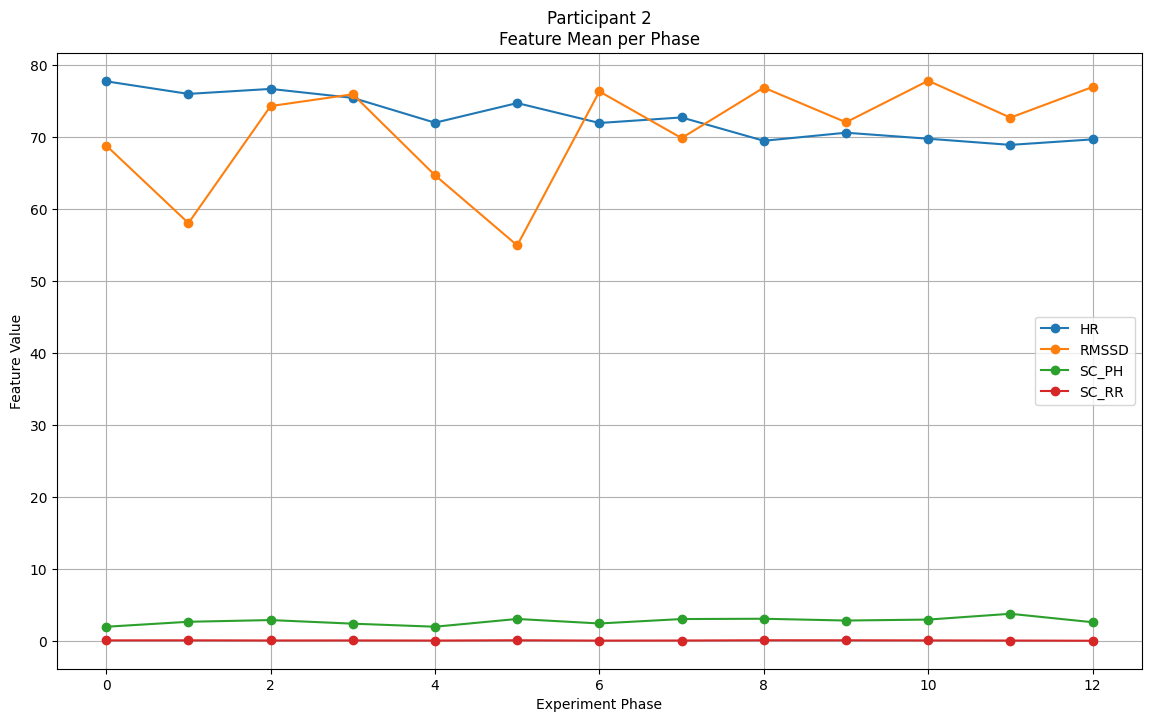

In [18]:
# ==========================================
# CELL 14
# FEATURE MEAN PER PHASE
# ==========================================

participant_id = 2

participant_df = combined_df[
    combined_df["Participant"] == participant_id
]

# ==========================================
# GROUP BY PHASE
# ==========================================

phase_means = (
    participant_df
    .groupby("Experiment_Phase")[
        ["HR", "RMSSD", "SC_PH", "SC_RR"]
    ]
    .mean()
)

# ==========================================
# PLOT
# ==========================================

phase_means.plot(
    figsize=(14,8),
    marker='o'
)

plt.title(
    f"Participant {participant_id}\nFeature Mean per Phase"
)

plt.xlabel("Experiment Phase")

plt.ylabel("Feature Value")

plt.grid(True)

plt.show()

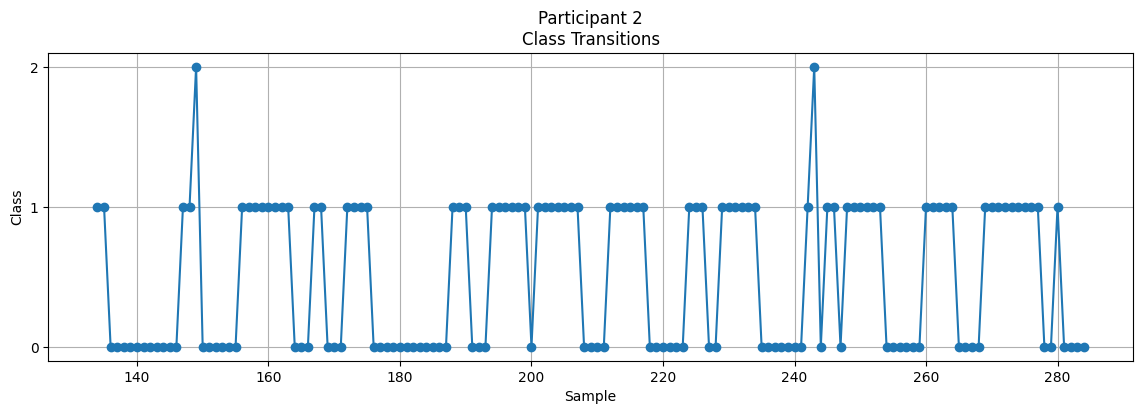

In [19]:
# ==========================================
# CELL 15
# CLASS TRANSITIONS OVER TIME
# ==========================================

participant_id = 2

participant_df = combined_df[
    combined_df["Participant"] == participant_id
]

# ==========================================
# PLOT
# ==========================================

plt.figure(figsize=(14,4))

plt.plot(
    participant_df[classification_col],
    marker='o'
)

# ==========================================
# STYLE
# ==========================================

plt.yticks([0,1,2])

plt.xlabel("Sample")

plt.ylabel("Class")

plt.title(
    f"Participant {participant_id}\nClass Transitions"
)

plt.grid(True)

plt.show()

C:\Users\pat19\AppData\Local\Temp\ipykernel_14540\2321501807.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\pat19\AppData\Local\Temp\ipykernel_14540\2321501807.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\pat19\AppData\Local\Temp\ipykernel_14540\2321501807.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\pat19\AppData\Local\Temp\ipykernel_14540\2321501807.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

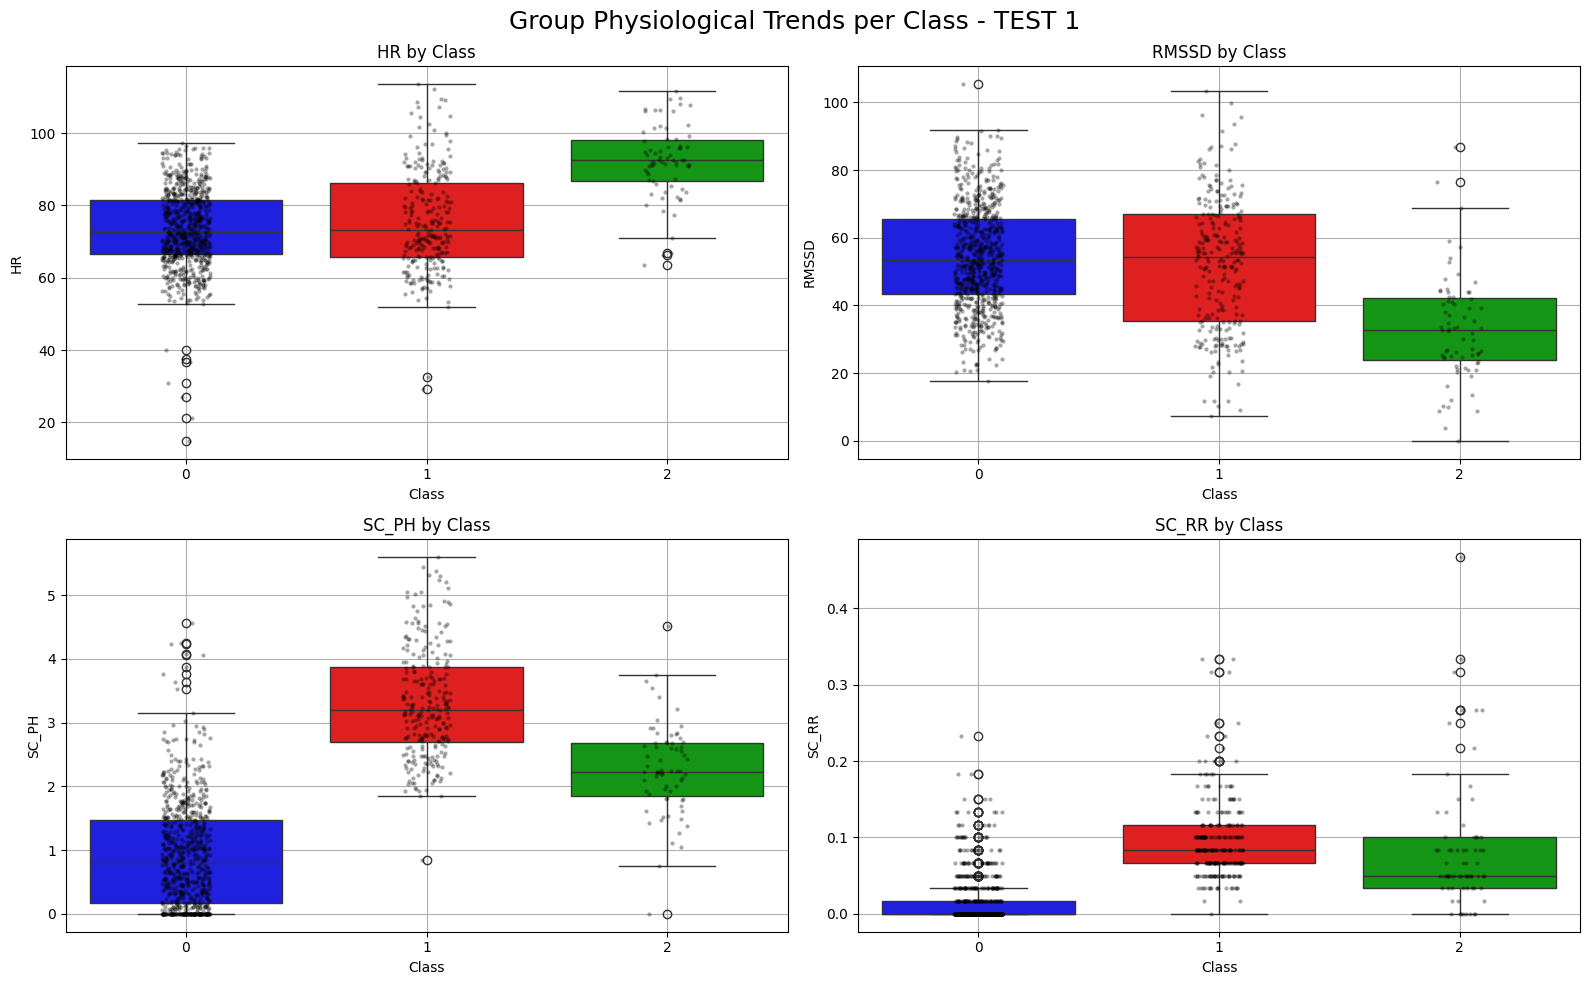

: 

In [ ]:
# ==========================================
# CELL 16
# GROUP FEATURE TRENDS PER CLASS
# ==========================================

import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# REMOVE INVALID CLASS
# ==========================================

plot_df = combined_df[
    combined_df[classification_col] != 255
].copy()

# ==========================================
# CONVERT CLASS TO STRING
# ==========================================

plot_df[classification_col] = (
    plot_df[classification_col]
    .astype(str)
)

# ==========================================
# FEATURES
# ==========================================

features = [
    "HR",
    "RMSSD",
    "SC_PH",
    "SC_RR"
]

# ==========================================
# COLORS
# ==========================================

palette = {
    "0": "#0000FF",   # Blue
    "1": "#FF0000",   # Red
    "2": "#00AA00"    # Green
}

# ==========================================
# CREATE FIGURE
# ==========================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16,10)
)

axes = axes.flatten()

# ==========================================
# PLOT FEATURES
# ==========================================

for i, feature in enumerate(features):

    sns.boxplot(
        data=plot_df,
        x=classification_col,
        y=feature,
        palette=palette,
        ax=axes[i]
    )

    sns.stripplot(
        data=plot_df,
        x=classification_col,
        y=feature,
        color='black',
        alpha=0.35,
        size=3,
        ax=axes[i]
    )

    # --------------------------------------
    # STYLE
    # --------------------------------------

    axes[i].set_title(
        f"{feature} by Class"
    )

    axes[i].set_xlabel(
        "Class"
    )

    axes[i].grid(True)

# ==========================================
# FINAL
# ==========================================

plt.suptitle(
    "Group Physiological Trends per Class - TEST 1",
    fontsize=18
)

plt.tight_layout()

plt.show()

C:\Users\pat19\AppData\Local\Temp\ipykernel_14540\3746656392.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\pat19\AppData\Local\Temp\ipykernel_14540\3746656392.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\pat19\AppData\Local\Temp\ipykernel_14540\3746656392.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\pat19\AppData\Local\Temp\ipykernel_14540\3746656392.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

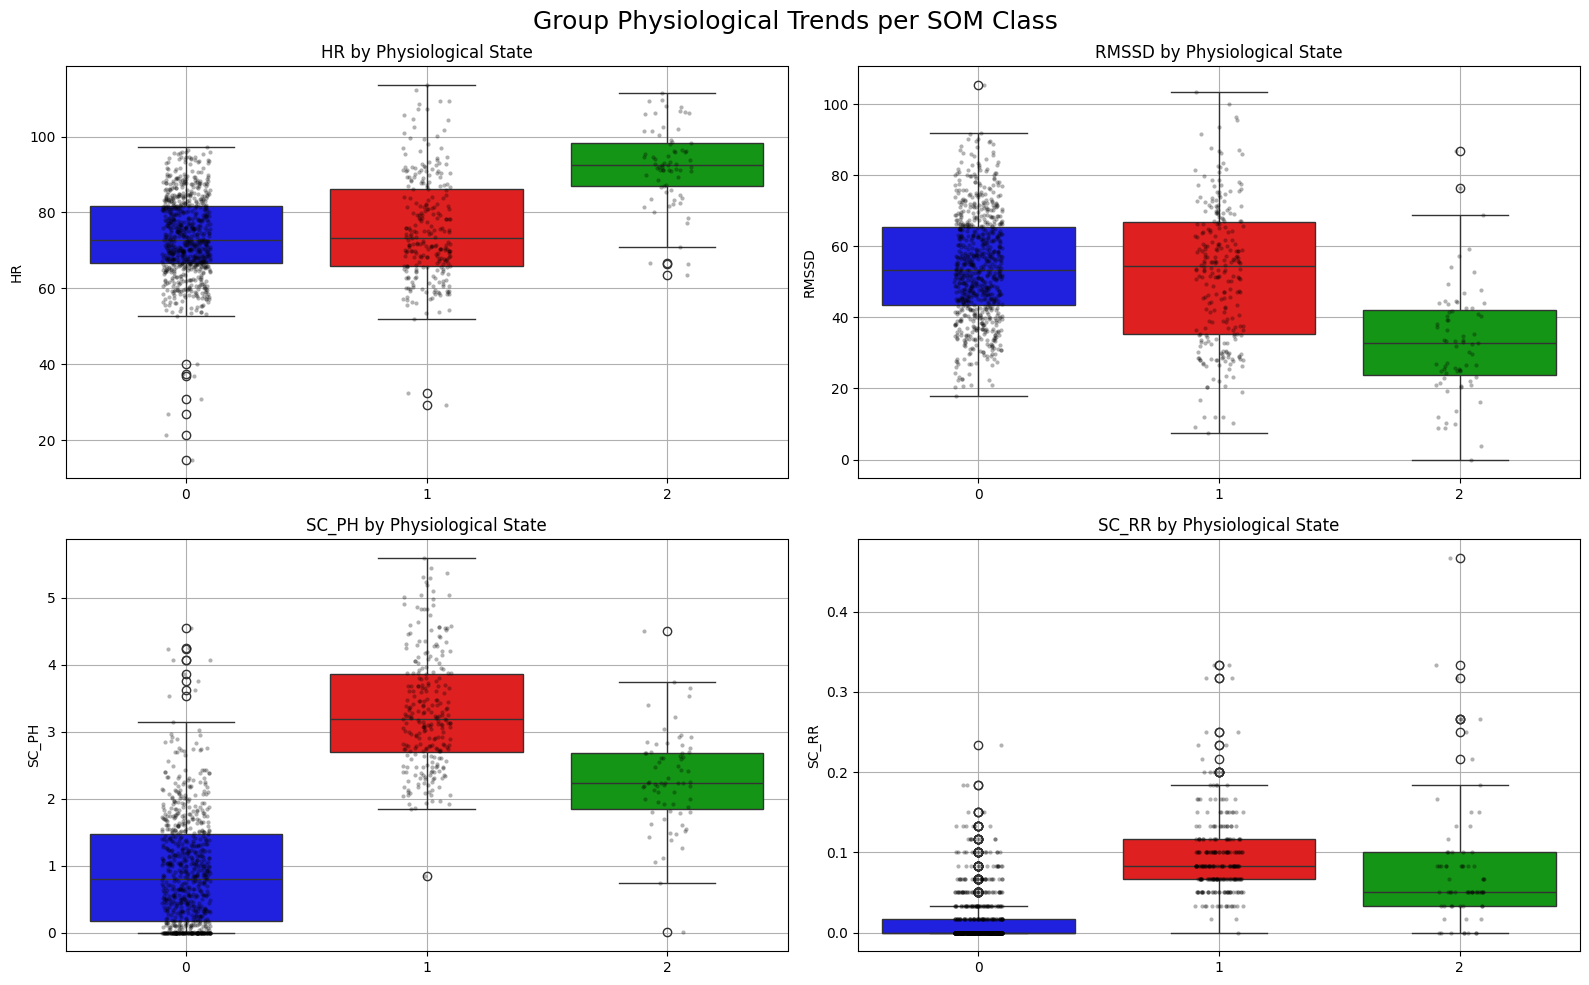



PHYSIOLOGICAL CLASS STATISTICS


HR
            count   mean  median    std    min     max
Class_Name                                            
0             756  73.57   72.75  10.80  14.86   97.17
1             260  75.66   73.31  13.77  29.16  113.57
2              71  92.24   92.61  10.17  63.54  111.58


RMSSD
            count   mean  median    std    min     max
Class_Name                                            
0             756  54.23   53.31  14.94  17.80  105.37
1             260  52.42   54.41  19.29   7.41  103.37
2              71  33.10   32.69  15.78   0.00   86.68


SC_PH
            count  mean  median   std   min   max
Class_Name                                       
0             757  0.92    0.80  0.83  0.00  4.56
1             259  3.29    3.19  0.86  0.84  5.59
2              71  2.27    2.23  0.72  0.01  4.51


SC_RR
            count  mean  median   std  min   max
Class_Name                                      
0             757  0.02    0.00  0.03  0

In [50]:
# ==========================================
# CELL 16B
# GROUP PHYSIOLOGICAL TRENDS + STATISTICS
# ==========================================

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================
# REMOVE INVALID CLASS
# ==========================================

plot_df = combined_df[
    combined_df[classification_col] != 255
].copy()

# ==========================================
# RENAME CLASSES
# ==========================================

class_names = {
    0: "0",
    1: "1",
    2: "2"
}

plot_df["Class_Name"] = (
    plot_df[classification_col]
    .map(class_names)
)

# ==========================================
# FEATURES
# ==========================================

features = [
    "HR",
    "RMSSD",
    "SC_PH",
    "SC_RR"
]

# ==========================================
# COLORS
# ==========================================

palette = {
    "0": "#0000FF",
    "1": "#FF0000",
    "2": "#00AA00"
}

# ==========================================
# CREATE FIGURE
# ==========================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16,10)
)

axes = axes.flatten()

# ==========================================
# PLOT FEATURES
# ==========================================

for i, feature in enumerate(features):

    sns.boxplot(
        data=plot_df,
        x="Class_Name",
        y=feature,
        palette=palette,
        ax=axes[i]
    )

    sns.stripplot(
        data=plot_df,
        x="Class_Name",
        y=feature,
        color='black',
        alpha=0.30,
        size=3,
        ax=axes[i]
    )

    axes[i].set_title(
        f"{feature} by Physiological State"
    )

    axes[i].set_xlabel("")

    axes[i].grid(True)

# ==========================================
# FINAL FIGURE
# ==========================================

plt.suptitle(
    "Group Physiological Trends per SOM Class",
    fontsize=18
)

plt.tight_layout()

plt.show()

# ==========================================
# STATISTICAL SUMMARY
# ==========================================

print("\n")
print("=========================================")
print("PHYSIOLOGICAL CLASS STATISTICS")
print("=========================================")

for feature in features:

    print("\n")
    print("=====================================")
    print(f"{feature}")
    print("=====================================")

    stats_df = (
        plot_df
        .groupby("Class_Name")[feature]
        .agg([
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max"
        ])
        .round(2)
    )

    print(stats_df)

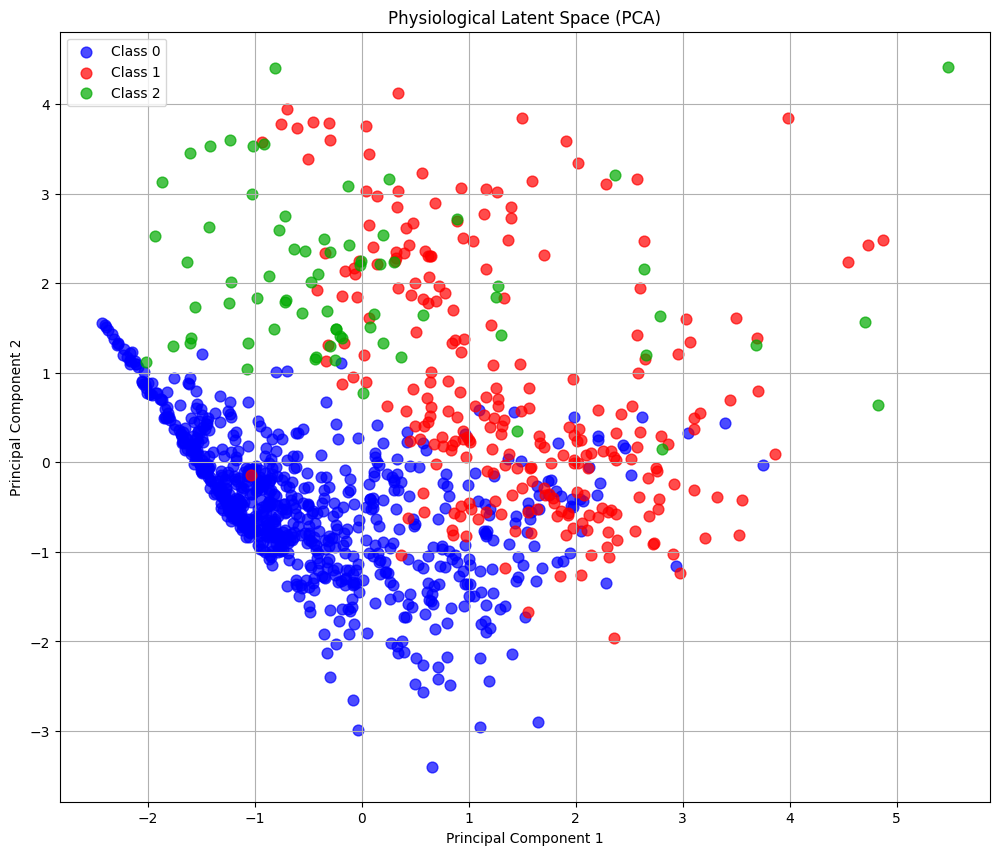


Explained variance ratio:
[0.46590686 0.36839779]

Total explained variance:
0.834304653795487


In [26]:
# ==========================================
# CELL 20
# PCA LATENT SPACE
# ==========================================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ==========================================
# REMOVE INVALID CLASS
# ==========================================

plot_df = combined_df[
    combined_df[classification_col] != 255
].copy()

# ==========================================
# FEATURES
# ==========================================

features = [
    "HR",
    "RMSSD",
    "SC_PH",
    "SC_RR"
]

# ==========================================
# REMOVE NaN
# ==========================================

plot_df = plot_df.dropna(
    subset=features
)

# ==========================================
# FEATURE MATRIX
# ==========================================

X = plot_df[features]

# ==========================================
# SCALE
# ==========================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ==========================================
# PCA
# ==========================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# ==========================================
# STORE PCA
# ==========================================

plot_df["PC1"] = X_pca[:,0]
plot_df["PC2"] = X_pca[:,1]

# ==========================================
# COLORS
# ==========================================

palette = {
    0: "#0000FF",
    1: "#FF0000",
    2: "#00AA00"
}

# ==========================================
# PLOT
# ==========================================

plt.figure(figsize=(12,10))

for c in [0,1,2]:

    class_df = plot_df[
        plot_df[classification_col] == c
    ]

    plt.scatter(
        class_df["PC1"],
        class_df["PC2"],
        label=f"Class {c}",
        alpha=0.7,
        s=60,
        color=palette[c]
    )

# ==========================================
# STYLE
# ==========================================

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title(
    "Physiological Latent Space (PCA)"
)

plt.legend()

plt.grid(True)

plt.show()

# ==========================================
# EXPLAINED VARIANCE
# ==========================================

print("\nExplained variance ratio:")

print(
    pca.explained_variance_ratio_
)

print(
    "\nTotal explained variance:"
)

print(
    pca.explained_variance_ratio_.sum()
)

CLUSTER CENTROIDS
                                HR      RMSSD     SC_PH     SC_RR
baseline_classification                                          
0                        73.570803  54.226227  0.918209  0.015940
1                        75.656299  52.420659  3.291958  0.096154
2                        92.243151  33.098288  2.269095  0.087793


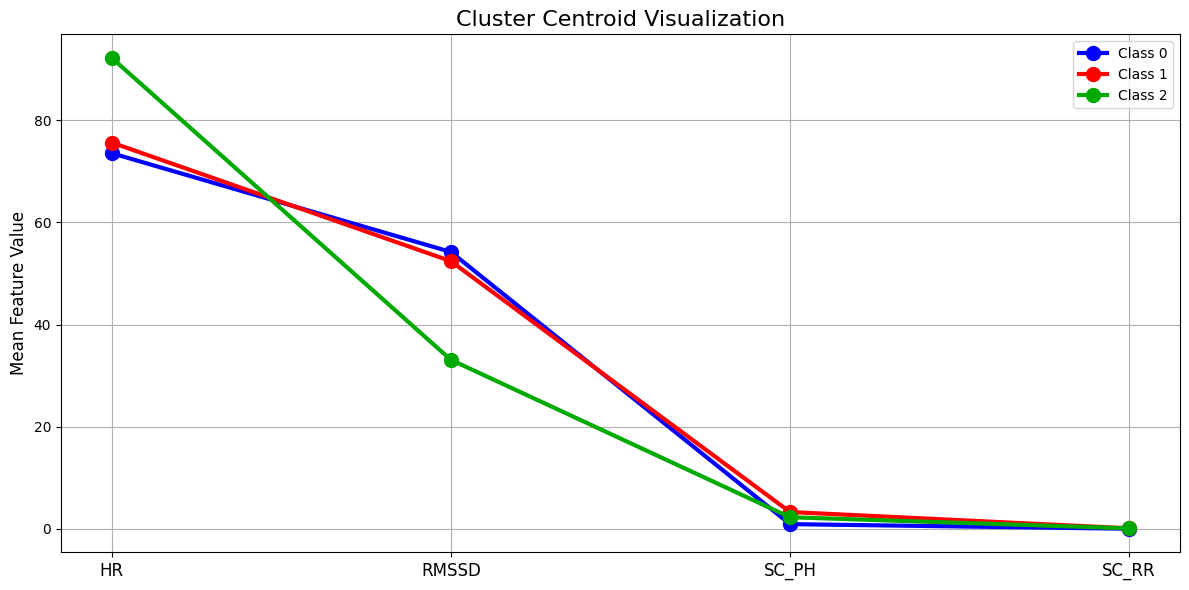

In [27]:
# ==========================================
# CELL 21
# CLUSTER CENTROID VISUALIZATION
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# REMOVE INVALID CLASS
# ==========================================

plot_df = combined_df[
    combined_df[classification_col] != 255
].copy()

# ==========================================
# FEATURES
# ==========================================

features = [
    "HR",
    "RMSSD",
    "SC_PH",
    "SC_RR"
]

# ==========================================
# CALCULATE CENTROIDS
# ==========================================

centroids = (
    plot_df
    .groupby(classification_col)[features]
    .mean()
)

print("=================================")
print("CLUSTER CENTROIDS")
print("=================================")

print(centroids)

# ==========================================
# CREATE FIGURE
# ==========================================

fig, ax = plt.subplots(
    figsize=(12,6)
)

# ==========================================
# X POSITIONS
# ==========================================

x = np.arange(len(features))

# ==========================================
# COLORS
# ==========================================

colors = {
    0: "#0000FF",
    1: "#FF0000",
    2: "#00AA00"
}

# ==========================================
# PLOT CLUSTERS
# ==========================================

for c in [0,1,2]:

    values = centroids.loc[c]

    ax.plot(
        x,
        values,
        marker='o',
        linewidth=3,
        markersize=10,
        label=f"Class {c}",
        color=colors[c]
    )

# ==========================================
# STYLE
# ==========================================

ax.set_xticks(x)

ax.set_xticklabels(
    features,
    fontsize=12
)

ax.set_ylabel(
    "Mean Feature Value",
    fontsize=12
)

ax.set_title(
    "Cluster Centroid Visualization",
    fontsize=16
)

ax.grid(True)

ax.legend()

plt.tight_layout()

plt.show()

In [29]:
# ==========================================
# CELL 23
# STATISTICAL SIGNIFICANCE TESTS
# ANOVA + KRUSKAL-WALLIS
# ==========================================

from scipy.stats import f_oneway
from scipy.stats import kruskal
import pandas as pd

# ==========================================
# REMOVE INVALID CLASS
# ==========================================

stats_df = combined_df[
    combined_df[classification_col] != 255
].copy()

# ==========================================
# FEATURES
# ==========================================

features = [
    "HR",
    "RMSSD",
    "SC_PH",
    "SC_RR"
]

# ==========================================
# CLASS NAMES
# ==========================================

class_names = {
    0: "Rest",
    1: "Active / Mild Stress",
    2: "Stress"
}

# ==========================================
# RESULTS
# ==========================================

results = []

# ==========================================
# LOOP FEATURES
# ==========================================

for feature in features:

    # --------------------------------------
    # REMOVE NaN
    # --------------------------------------

    feature_df = stats_df.dropna(
        subset=[feature]
    )

    # --------------------------------------
    # GROUPS
    # --------------------------------------

    class0 = feature_df[
        feature_df[classification_col] == 0
    ][feature]

    class1 = feature_df[
        feature_df[classification_col] == 1
    ][feature]

    class2 = feature_df[
        feature_df[classification_col] == 2
    ][feature]

    # --------------------------------------
    # ANOVA
    # --------------------------------------

    anova_stat, anova_p = f_oneway(
        class0,
        class1,
        class2
    )

    # --------------------------------------
    # KRUSKAL-WALLIS
    # --------------------------------------

    kruskal_stat, kruskal_p = kruskal(
        class0,
        class1,
        class2
    )

    # --------------------------------------
    # SAVE RESULTS
    # --------------------------------------

    results.append({

        "Feature": feature,

        "ANOVA_F": round(anova_stat, 4),

        "ANOVA_p": round(anova_p, 10),

        "Kruskal_H": round(kruskal_stat, 4),

        "Kruskal_p": round(kruskal_p, 10)

    })

# ==========================================
# RESULTS DATAFRAME
# ==========================================

results_df = pd.DataFrame(results)

# ==========================================
# PRINT RESULTS
# ==========================================

print("\n=========================================")
print("STATISTICAL SIGNIFICANCE TESTS")
print("=========================================")

print(results_df)

# ==========================================
# INTERPRETATION
# ==========================================

print("\n")
print("=========================================")
print("INTERPRETATION")
print("=========================================")

for _, row in results_df.iterrows():

    print(f"\nFeature: {row['Feature']}")

    # --------------------------------------
    # ANOVA
    # --------------------------------------

    if row["ANOVA_p"] < 0.05:

        print(
            f"ANOVA: Significant difference "
            f"between classes "
            f"(p = {row['ANOVA_p']})"
        )

    else:

        print(
            f"ANOVA: No significant difference "
            f"(p = {row['ANOVA_p']})"
        )

    # --------------------------------------
    # KRUSKAL
    # --------------------------------------

    if row["Kruskal_p"] < 0.05:

        print(
            f"Kruskal-Wallis: Significant difference "
            f"between classes "
            f"(p = {row['Kruskal_p']})"
        )

    else:

        print(
            f"Kruskal-Wallis: No significant difference "
            f"(p = {row['Kruskal_p']})"
        )


STATISTICAL SIGNIFICANCE TESTS
  Feature   ANOVA_F  ANOVA_p  Kruskal_H  Kruskal_p
0      HR   85.0991      0.0   117.6127        0.0
1   RMSSD   55.6159      0.0    87.5765        0.0
2   SC_PH  820.0258      0.0   591.2530        0.0
3   SC_RR  381.2225      0.0   547.7410        0.0


INTERPRETATION

Feature: HR
ANOVA: Significant difference between classes (p = 0.0)
Kruskal-Wallis: Significant difference between classes (p = 0.0)

Feature: RMSSD
ANOVA: Significant difference between classes (p = 0.0)
Kruskal-Wallis: Significant difference between classes (p = 0.0)

Feature: SC_PH
ANOVA: Significant difference between classes (p = 0.0)
Kruskal-Wallis: Significant difference between classes (p = 0.0)

Feature: SC_RR
ANOVA: Significant difference between classes (p = 0.0)
Kruskal-Wallis: Significant difference between classes (p = 0.0)


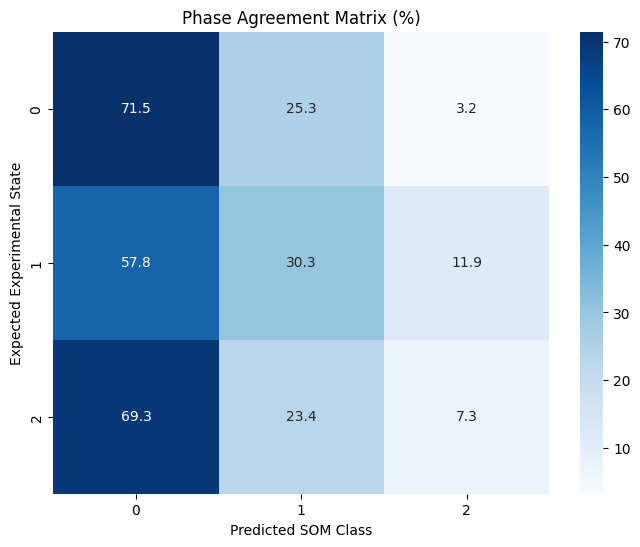

baseline_classification          0          1          2
Expected_Class                                          
0                        71.459227  25.321888   3.218884
1                        57.798165  30.275229  11.926606
2                        69.266055  23.394495   7.339450


In [30]:
# ==========================================
# CELL 24
# PHASE AGREEMENT MATRIX
# ==========================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# COPY DATA
# ==========================================

eval_df = combined_df.copy()

# ==========================================
# REMOVE INVALID CLASS
# ==========================================

eval_df = eval_df[
    eval_df[classification_col] != 255
]

# ==========================================
# EXPECTED STATES
# ==========================================

def expected_state(phase):

    if phase in [2,4,6,8,10,12]:
        return 0  # Rest

    elif phase in [1,3,5]:
        return 1  # Mild Stress

    elif phase in [7,9,11]:
        return 2  # Stress

    else:
        return -1

eval_df["Expected_Class"] = (
    eval_df["Experiment_Phase"]
    .apply(expected_state)
)

# ==========================================
# REMOVE BASELINE
# ==========================================

eval_df = eval_df[
    eval_df["Expected_Class"] != -1
]

# ==========================================
# CONFUSION MATRIX
# ==========================================

conf_matrix = pd.crosstab(
    eval_df["Expected_Class"],
    eval_df[classification_col],
    normalize='index'
) * 100

# ==========================================
# PLOT
# ==========================================

plt.figure(figsize=(8,6))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

# ==========================================
# STYLE
# ==========================================

plt.title(
    "Phase Agreement Matrix (%)"
)

plt.xlabel(
    "Predicted SOM Class"
)

plt.ylabel(
    "Expected Experimental State"
)

plt.show()

print(conf_matrix)

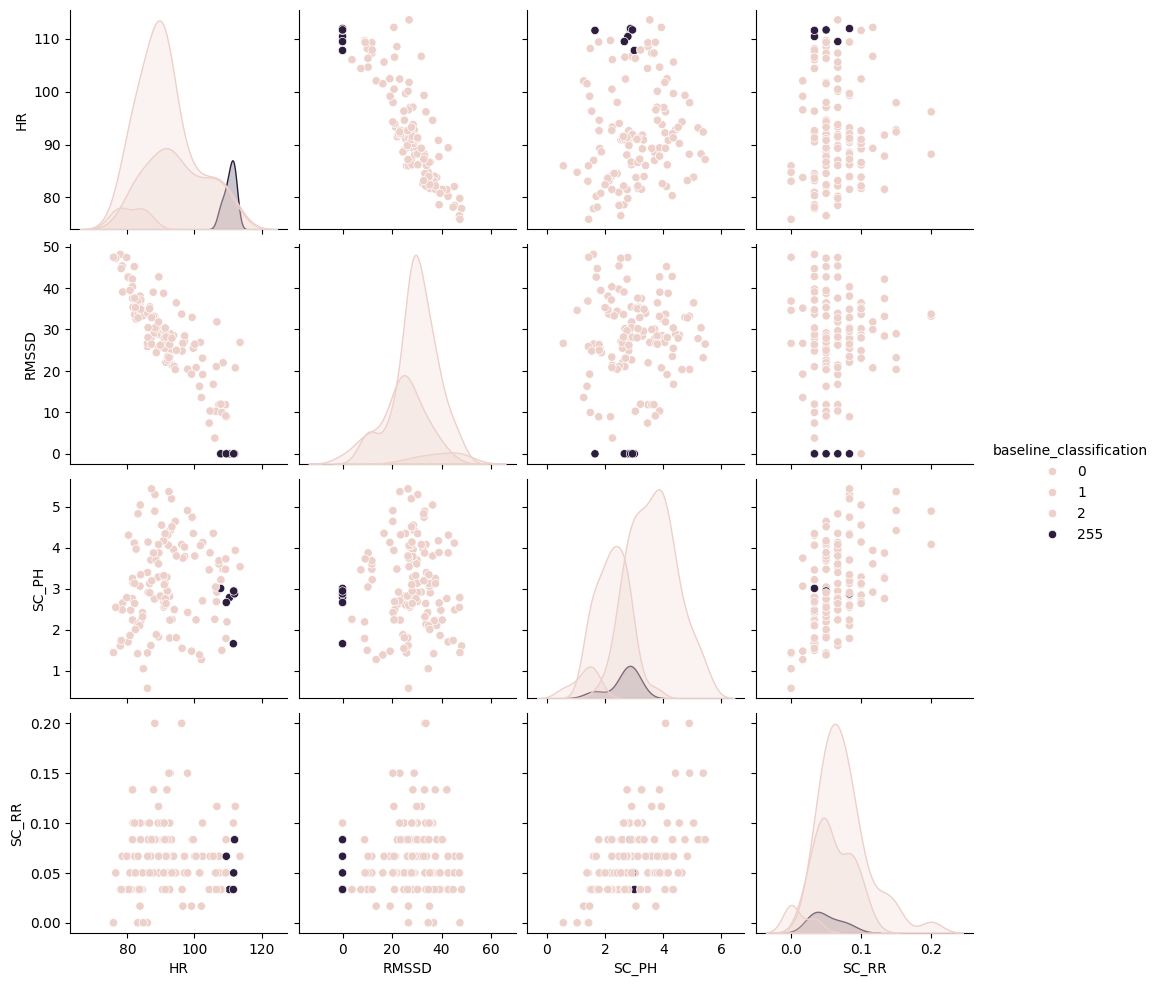

In [ ]:
# ==========================================
# CELL 13
# FEATURE SCATTER MATRIX
# ==========================================

import seaborn as sns

participant_id = 5

participant_df = combined_df[
    combined_df["Participant"] == participant_id
]

# ==========================================
# FEATURES
# ==========================================

plot_df = participant_df[
    [
        "HR",
        "RMSSD",
        "SC_PH",
        "SC_RR",
        classification_col
    ]
]

# ==========================================
# PAIRPLOT
# ==========================================

sns.pairplot(
    plot_df,
    hue=classification_col
)

plt.show()

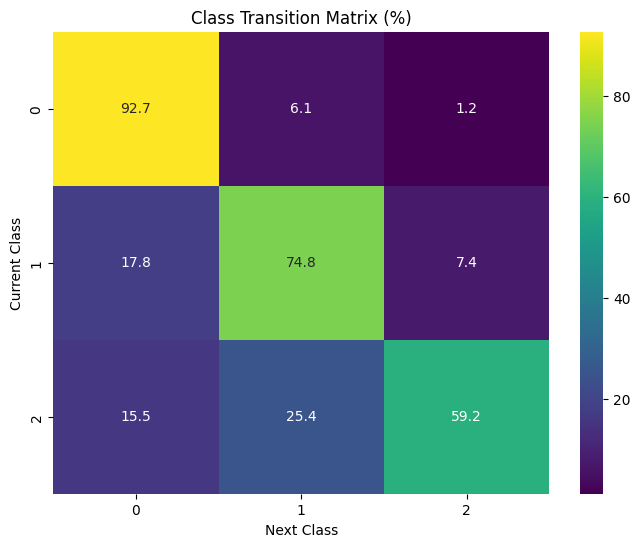

In [31]:
# ==========================================
# CELL 25
# TRANSITION MATRIX
# ==========================================

import numpy as np

# ==========================================
# TRANSITIONS
# ==========================================

transitions = np.zeros((3,3))

# ==========================================
# LOOP PARTICIPANTS
# ==========================================

participants = sorted(
    combined_df["Participant"].unique()
)

for participant in participants:

    participant_df = combined_df[
        combined_df["Participant"] == participant
    ]

    participant_df = participant_df[
        participant_df[classification_col] != 255
    ]

    classes = (
        participant_df[classification_col]
        .values
    )

    # --------------------------------------
    # COUNT TRANSITIONS
    # --------------------------------------

    for i in range(len(classes)-1):

        current_class = int(classes[i])

        next_class = int(classes[i+1])

        transitions[
            current_class,
            next_class
        ] += 1

# ==========================================
# NORMALIZE
# ==========================================

transition_percent = (
    transitions /
    transitions.sum(axis=1, keepdims=True)
) * 100

# ==========================================
# PLOT
# ==========================================

plt.figure(figsize=(8,6))

sns.heatmap(
    transition_percent,
    annot=True,
    fmt=".1f",
    cmap="viridis"
)

# ==========================================
# STYLE
# ==========================================

plt.title(
    "Class Transition Matrix (%)"
)

plt.xlabel(
    "Next Class"
)

plt.ylabel(
    "Current Class"
)

plt.show()

   Participant  Transitions  Stability_Percent
0            1           22          83.458647
1            2           35          76.666667
2            3           15          88.888889
3            4           25          82.142857
4            5           33          73.600000
5            6            2          98.507463
6            7            2          98.461538
7            8           15          88.721805


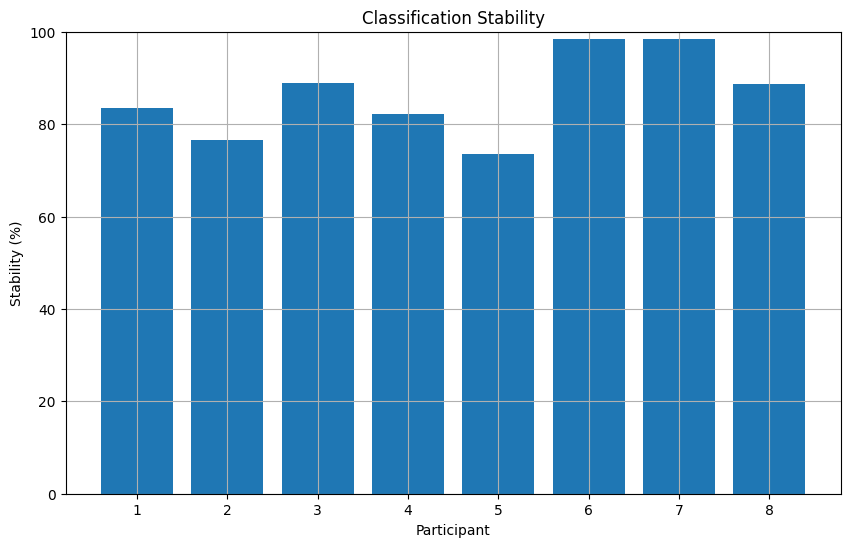

In [32]:
# ==========================================
# CELL 26
# CLASS STABILITY ANALYSIS
# ==========================================

# ==========================================
# RESULTS
# ==========================================

stability_results = []

# ==========================================
# LOOP PARTICIPANTS
# ==========================================

for participant in participants:

    participant_df = combined_df[
        combined_df["Participant"] == participant
    ]

    participant_df = participant_df[
        participant_df[classification_col] != 255
    ]

    classes = (
        participant_df[classification_col]
        .values
    )

    # --------------------------------------
    # COUNT CHANGES
    # --------------------------------------

    changes = 0

    for i in range(len(classes)-1):

        if classes[i] != classes[i+1]:

            changes += 1

    # --------------------------------------
    # STABILITY
    # --------------------------------------

    total_transitions = len(classes)-1

    stability = (
        1 - (changes / total_transitions)
    ) * 100

    stability_results.append({

        "Participant": participant,

        "Transitions": changes,

        "Stability_Percent": stability

    })

# ==========================================
# DATAFRAME
# ==========================================

stability_df = pd.DataFrame(
    stability_results
)

print(stability_df)

# ==========================================
# PLOT
# ==========================================

plt.figure(figsize=(10,6))

plt.bar(
    stability_df["Participant"],
    stability_df["Stability_Percent"]
)

# ==========================================
# STYLE
# ==========================================

plt.title(
    "Classification Stability"
)

plt.xlabel(
    "Participant"
)

plt.ylabel(
    "Stability (%)"
)

plt.ylim(0,100)

plt.grid(True)

plt.show()

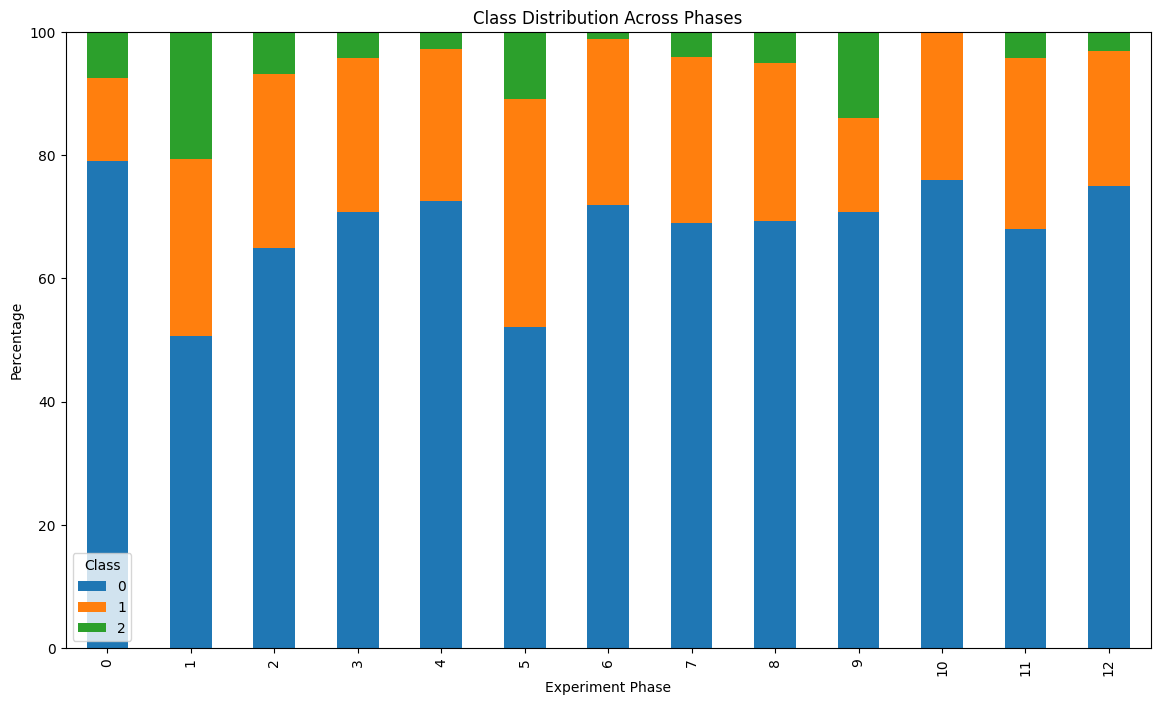

In [33]:
# ==========================================
# CELL 27
# CLASS DISTRIBUTION THROUGH PHASES
# ==========================================

phase_class = (
    combined_df
    .groupby(
        [
            "Experiment_Phase",
            classification_col
        ]
    )
    .size()
    .unstack(fill_value=0)
)

# ==========================================
# REMOVE INVALID CLASS
# ==========================================

if 255 in phase_class.columns:

    phase_class = phase_class.drop(
        columns=255
    )

# ==========================================
# NORMALIZE
# ==========================================

phase_class_percent = (
    phase_class.div(
        phase_class.sum(axis=1),
        axis=0
    ) * 100
)

# ==========================================
# PLOT
# ==========================================

phase_class_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(14,8)
)

# ==========================================
# STYLE
# ==========================================

plt.title(
    "Class Distribution Across Phases"
)

plt.xlabel(
    "Experiment Phase"
)

plt.ylabel(
    "Percentage"
)

plt.legend(
    title="Class"
)

plt.show()

                                             HR      RMSSD     SC_PH     SC_RR
Participant baseline_classification                                           
1           0                         59.843370  66.944635  1.606136  0.033673
            1                         60.059914  63.070408  2.841611  0.120833
2           0                         73.017946  73.686233  2.164597  0.068202
            1                         72.465690  68.395403  3.336765  0.103653
            2                         74.794834  81.505726  3.525080  0.325000
3           0                         77.694656  56.991571  0.699701  0.005055
            1                         66.105429  49.288220  2.021014  0.054167
            2                         90.160822  40.834830  1.804895  0.081667
4           0                         68.604835  65.562536  1.280158  0.020042
            1                         69.555334  61.867597  3.344259  0.104610
            2                         90.088086  45.

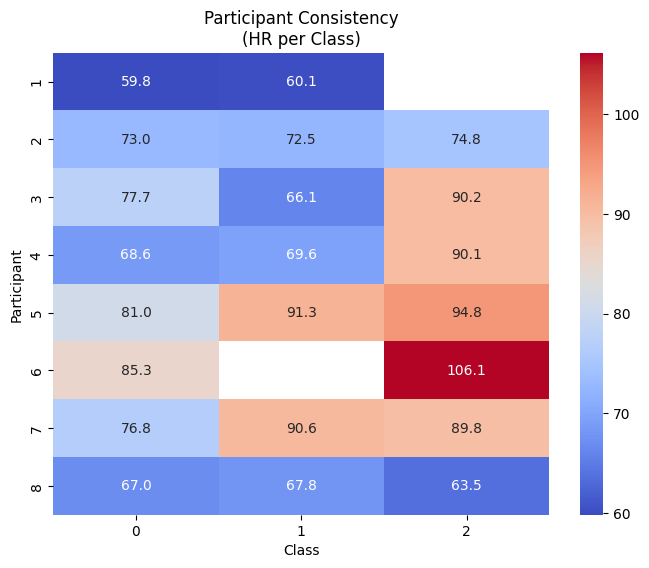

In [34]:
# ==========================================
# CELL 28
# PARTICIPANT CONSISTENCY ANALYSIS
# ==========================================

# ==========================================
# FEATURES
# ==========================================

features = [
    "HR",
    "RMSSD",
    "SC_PH",
    "SC_RR"
]

# ==========================================
# PARTICIPANT CENTROIDS
# ==========================================

participant_centroids = (
    combined_df[
        combined_df[classification_col] != 255
    ]
    .groupby(
        ["Participant", classification_col]
    )[features]
    .mean()
)

print(participant_centroids)

# ==========================================
# HEATMAP PREP
# ==========================================

heatmap_data = (
    participant_centroids
    .reset_index()
)

# ==========================================
# EXAMPLE FEATURE
# ==========================================

pivot_df = heatmap_data.pivot(
    index="Participant",
    columns=classification_col,
    values="HR"
)

# ==========================================
# PLOT
# ==========================================

plt.figure(figsize=(8,6))

sns.heatmap(
    pivot_df,
    annot=True,
    fmt=".1f",
    cmap="coolwarm"
)

# ==========================================
# STYLE
# ==========================================

plt.title(
    "Participant Consistency\n(HR per Class)"
)

plt.xlabel(
    "Class"
)

plt.ylabel(
    "Participant"
)

plt.show()

baseline_classification          0          1          2
Participant                                             
1                        73.134328  26.865672   0.000000
2                        50.331126  48.344371   1.324503
3                        89.705882   2.941176   7.352941
4                        56.028369  33.333333  10.638298
5                         4.761905  62.698413  32.539683
6                        99.259259   0.000000   0.740741
7                        97.709924   1.526718   0.763359
8                        85.074627  14.179104   0.746269


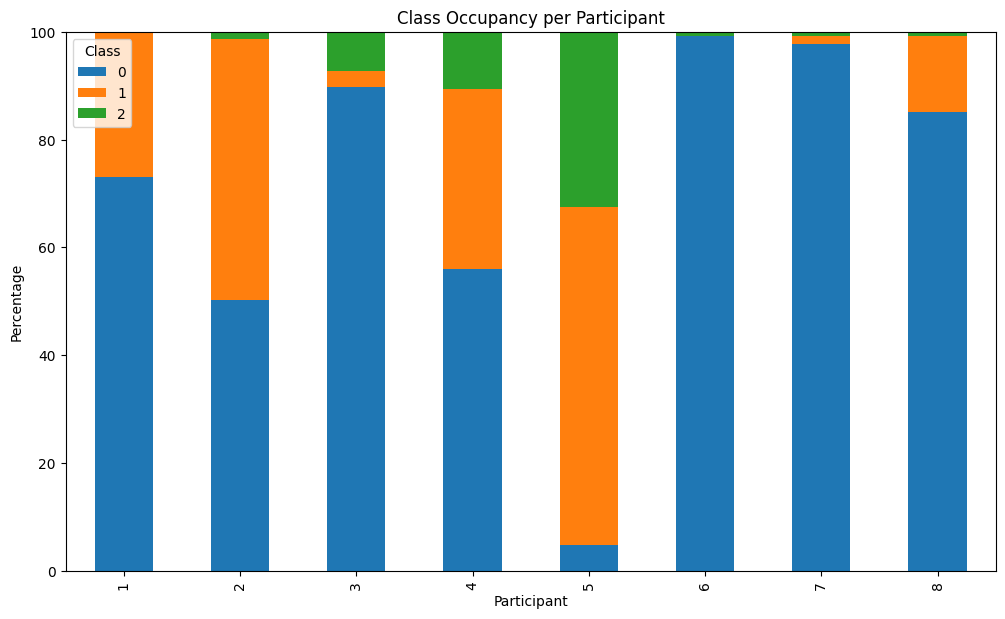

In [35]:
# ==========================================
# CELL 29
# CLASS OCCUPANCY ANALYSIS
# ==========================================

occupancy = (
    combined_df[
        combined_df[classification_col] != 255
    ]
    .groupby(
        ["Participant", classification_col]
    )
    .size()
    .unstack(fill_value=0)
)

# ==========================================
# NORMALIZE
# ==========================================

occupancy_percent = (
    occupancy.div(
        occupancy.sum(axis=1),
        axis=0
    ) * 100
)

print(occupancy_percent)

# ==========================================
# PLOT
# ==========================================

occupancy_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(12,7)
)

# ==========================================
# STYLE
# ==========================================

plt.title(
    "Class Occupancy per Participant"
)

plt.xlabel(
    "Participant"
)

plt.ylabel(
    "Percentage"
)

plt.legend(
    title="Class"
)

plt.show()

In [1]:
# ==========================================
# CELL 30
# PARTICIPANT-SPECIFIC PHASE ANALYSIS
# ==========================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("TEST 1")

# ==========================================
# REMOVE INVALID CLASS
# ==========================================

analysis_df = combined_df[
    combined_df[classification_col] != 255
].copy()

# ==========================================
# PHASE LABELS
# ==========================================

def phase_type(phase):

    if phase in [2,4,6,8,10,12]:
        return "Rest"

    elif phase in [1,3,5]:
        return "Stroop"

    elif phase in [7,9,11]:
        return "MAT"

    else:
        return "Baseline"

analysis_df["Phase_Type"] = (
    analysis_df["Experiment_Phase"]
    .apply(phase_type)
)

# ==========================================
# REMOVE BASELINE
# ==========================================

analysis_df = analysis_df[
    analysis_df["Phase_Type"] != "Baseline"
]

# ==========================================
# CREATE PIVOT TABLE
# ==========================================

participant_phase = (
    analysis_df
    .groupby(
        [
            "Participant",
            "Phase_Type",
            classification_col
        ]
    )
    .size()
    .reset_index(name="Count")
)

# ==========================================
# NORMALIZE PER PHASE
# ==========================================

participant_phase["Percent"] = (
    participant_phase.groupby(
        ["Participant", "Phase_Type"]
    )["Count"]
    .transform(
        lambda x: x / x.sum() * 100
    )
)

print(participant_phase.head())

# ==========================================
# CREATE FIGURE
# ==========================================

g = sns.catplot(
    data=participant_phase,
    x="Phase_Type",
    y="Percent",
    hue=classification_col,
    col="Participant",
    kind="bar",
    col_wrap=4,
    height=4,
    aspect=1.2,
    palette={
        0: "#0000FF",
        1: "#FF0000",
        2: "#00AA00"
    }
)

# ==========================================
# STYLE
# ==========================================

g.set_titles(
    "Participant {col_name}"
)

g.set_axis_labels(
    "Experimental Phase",
    "Classification Percentage"
)

# ==========================================
# FINAL
# ==========================================

plt.subplots_adjust(top=0.90)

g.fig.suptitle(
    "Participant-Specific Phase Analysis - test 1",
    fontsize=18
)

plt.show()

TEST 1


NameError: name 'combined_df' is not defined

In [38]:
# ==========================================
# CELL 31
# CLEAN PARTICIPANT PHASE TABLE
# ==========================================

import pandas as pd

# ==========================================
# REMOVE INVALID CLASS
# ==========================================

table_df = combined_df[
    combined_df[classification_col] != 255
].copy()

# ==========================================
# PHASE LABELS
# ==========================================

def phase_type(phase):

    if phase in [2,4,6,8,10,12]:
        return "Rest"

    elif phase in [1,3,5]:
        return "Active / Mild Stress"

    elif phase in [7,9,11]:
        return "Stress"

    else:
        return "Baseline"

table_df["Phase_Type"] = (
    table_df["Experiment_Phase"]
    .apply(phase_type)
)

# ==========================================
# REMOVE BASELINE
# ==========================================

table_df = table_df[
    table_df["Phase_Type"] != "Baseline"
]

# ==========================================
# CREATE SUMMARY
# ==========================================

summary = (
    table_df
    .groupby(
        [
            "Participant",
            "Phase_Type",
            classification_col
        ]
    )
    .size()
    .reset_index(name="Count")
)

# ==========================================
# PERCENT
# ==========================================

summary["Percent"] = (
    summary.groupby(
        ["Participant", "Phase_Type"]
    )["Count"]
    .transform(
        lambda x: x / x.sum() * 100
    )
)

# ==========================================
# ROUND
# ==========================================

summary["Percent"] = (
    summary["Percent"]
    .round(1)
)

# ==========================================
# SORT
# ==========================================

summary = summary.sort_values(
    [
        "Participant",
        "Phase_Type",
        classification_col
    ]
)

# ==========================================
# PRINT ALL PARTICIPANTS
# ==========================================

participants = sorted(
    summary["Participant"].unique()
)

for participant in participants:

    print("\n")
    print("===================================================")
    print(f"PARTICIPANT {participant}")
    print("===================================================")

    participant_df = summary[
        summary["Participant"] == participant
    ]

    print(
        participant_df.to_string(index=False)
    )



PARTICIPANT 1
 Participant           Phase_Type  baseline_classification  Count  Percent
           1 Active / Mild Stress                        0     15     53.6
           1 Active / Mild Stress                        1     13     46.4
           1                 Rest                        0     46     82.1
           1                 Rest                        1     10     17.9
           1               Stress                        0     21     77.8
           1               Stress                        1      6     22.2


PARTICIPANT 2
 Participant           Phase_Type  baseline_classification  Count  Percent
           2 Active / Mild Stress                        0     13     46.4
           2 Active / Mild Stress                        1     15     53.6
           2                 Rest                        0     36     48.6
           2                 Rest                        1     37     50.0
           2                 Rest                        2      1   

In [45]:
# ==========================================
# CELL 32
# FEATURE CHANGE DURING CLASS TRANSITIONS
# ==========================================

import pandas as pd
import numpy as np

# ==========================================
# FEATURES
# ==========================================

features = [
    "HR",
    "RMSSD",
    "SC_PH",
    "SC_RR"
]

# ==========================================
# REMOVE INVALID CLASS
# ==========================================

transition_df = combined_df[
    combined_df[classification_col] != 255
].copy()

# ==========================================
# STORE RESULTS
# ==========================================

transition_results = []

# ==========================================
# LOOP PARTICIPANTS
# ==========================================

participants = sorted(
    transition_df["Participant"].unique()
)

for participant in participants:

    participant_df = transition_df[
        transition_df["Participant"] == participant
    ].copy()

    participant_df = (
        participant_df
        .reset_index(drop=True)
    )

    # --------------------------------------
    # LOOP TRANSITIONS
    # --------------------------------------

    for i in range(len(participant_df)-1):

        current_class = (
            participant_df.loc[
                i,
                classification_col
            ]
        )

        next_class = (
            participant_df.loc[
                i+1,
                classification_col
            ]
        )

        # ----------------------------------
        # ONLY REAL TRANSITIONS
        # ----------------------------------

        if current_class != next_class:

            result = {

                "Participant": participant,

                "Transition":
                f"{current_class} → {next_class}"

            }

            # ----------------------------------
            # FEATURE CHANGES
            # ----------------------------------

            for feature in features:

                current_value = (
                    participant_df.loc[i, feature]
                )

                next_value = (
                    participant_df.loc[i+1, feature]
                )

                delta = (
                    next_value - current_value
                )

                result[
                    f"Δ_{feature}"
                ] = delta

            transition_results.append(result)

# ==========================================
# DATAFRAME
# ==========================================

transition_results_df = pd.DataFrame(
    transition_results
)

# ==========================================
# ROUND
# ==========================================

for feature in features:

    transition_results_df[
        f"Δ_{feature}"
    ] = (
        transition_results_df[
            f"Δ_{feature}"
        ].round(2)
    )

# ==========================================
# PRINT
# ==========================================

print("\n")
print("=========================================")
print("FEATURE CHANGE DURING TRANSITIONS - TEST1")
print("=========================================")

print(
    transition_results_df
)



FEATURE CHANGE DURING TRANSITIONS - TEST1
     Participant Transition  Δ_HR  Δ_RMSSD  Δ_SC_PH  Δ_SC_RR
0              1      0 → 1  1.49     3.78     0.98     0.02
1              1      1 → 0  0.91     5.59    -0.40    -0.03
2              1      0 → 1 -0.48    -9.68     0.63     0.08
3              1      1 → 0 -2.76     2.30    -0.47    -0.10
4              1      0 → 1  0.46    -9.40     0.52     0.00
..           ...        ...   ...      ...      ...      ...
144            8      1 → 0 -0.66    -2.56    -0.41    -0.02
145            8      0 → 1  2.67     4.43     0.66     0.07
146            8      1 → 0  0.28     4.37    -0.32    -0.03
147            8      0 → 2  1.08     2.48     0.40     0.08
148            8      2 → 1  1.00     0.73     0.11    -0.02

[149 rows x 6 columns]


In [46]:
# ==========================================
# GROUPED TRANSITION SUMMARY
# ==========================================

transition_summary = (
    transition_results_df
    .groupby("Transition")
    [
        [
            "Δ_HR",
            "Δ_RMSSD",
            "Δ_SC_PH",
            "Δ_SC_RR"
        ]
    ]
    .agg(
        ["mean", "std", "count"]
    )
    .round(2)
)

transition_summary

Δ_HR             Δ_RMSSD             Δ_SC_PH             Δ_SC_RR  \
            mean   std count    mean   std count    mean   std count    mean   
Transition                                                                     
0 → 1       0.07  3.39    46   -0.78  5.89    45    1.23  1.14    46    0.04   
0 → 2       5.58  7.45     9   -3.14  5.72     9    0.72  0.99     9    0.08   
1 → 0       0.35  9.06    46    0.20  4.83    46   -0.78  0.66    46   -0.05   
1 → 2       1.67  5.56    19   -1.63  4.87    19   -0.84  0.53    19    0.00   
2 → 0      -1.99  8.35    11    1.68  5.37    11   -0.86  0.76    11   -0.10   
2 → 1      -3.38  6.66    18    1.36  5.60    18    0.89  1.02    18   -0.02   

                        
             std count  
Transition              
0 → 1       0.06    46  
0 → 2       0.09     9  
1 → 0       0.05    46  
1 → 2       0.07    19  
2 → 0       0.13    11  
2 → 1       0.08    18

TEST 1


   Participant Phase_Type  baseline_classification  Count    Percent
0            1       REST                        0     46  82.142857
1            1       REST                        1     10  17.857143
2            1     STROOP                        0     15  53.571429
3            1     STROOP                        1     13  46.428571
4            1        MAT                        0     21  77.777778


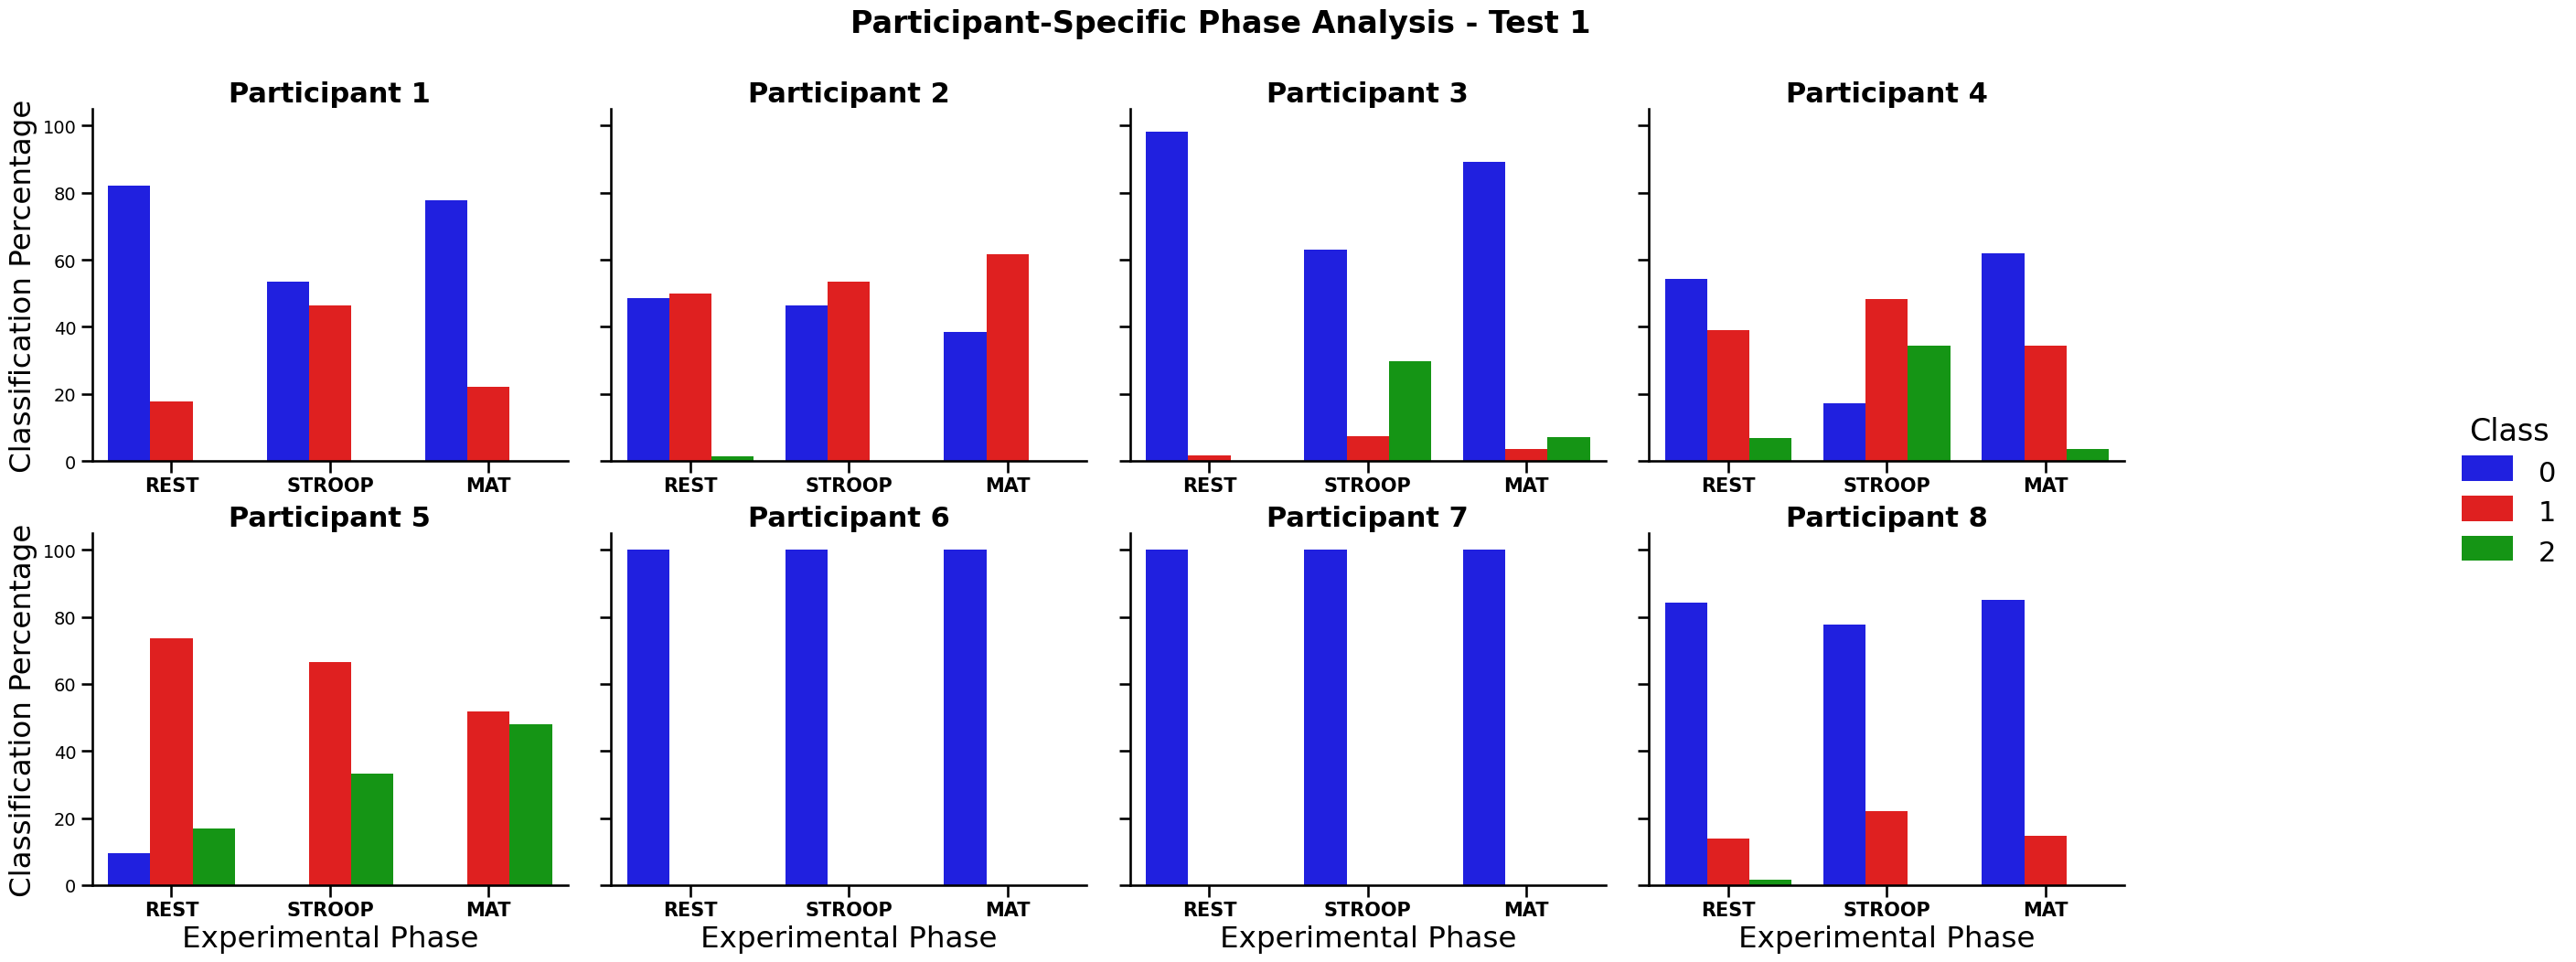

In [12]:
# ==========================================
# CELL 30
# PARTICIPANT-SPECIFIC PHASE ANALYSIS
# ==========================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("TEST 1")

# ==========================================
# REMOVE INVALID CLASS
# ==========================================

analysis_df = combined_df[
    combined_df[classification_col] != 255
].copy()

# ==========================================
# PHASE LABELS
# ==========================================

def phase_type(phase):

    if phase in [2,4,6,8,10,12]:
        return "REST"

    elif phase in [1,3,5]:
        return "STROOP"

    elif phase in [7,9,11]:
        return "MAT"

    else:
        return "Baseline"

analysis_df["Phase_Type"] = (
    analysis_df["Experiment_Phase"]
    .apply(phase_type)
)

# ==========================================
# REMOVE BASELINE
# ==========================================

analysis_df = analysis_df[
    analysis_df["Phase_Type"] != "Baseline"
]

# ==========================================
# FORCE SAME ORDER
# ==========================================

phase_order = ["REST", "STROOP", "MAT"]

analysis_df["Phase_Type"] = pd.Categorical(
    analysis_df["Phase_Type"],
    categories=phase_order,
    ordered=True
)

# ==========================================
# CREATE PIVOT TABLE
# ==========================================

participant_phase = (
    analysis_df
    .groupby(
        [
            "Participant",
            "Phase_Type",
            classification_col
        ]
    )
    .size()
    .reset_index(name="Count")
)

# ==========================================
# NORMALIZE PER PHASE
# ==========================================

participant_phase["Percent"] = (
    participant_phase.groupby(
        ["Participant", "Phase_Type"]
    )["Count"]
    .transform(
        lambda x: x / x.sum() * 100
    )
)

print(participant_phase.head())

# ==========================================
# BIGGER FONT
# ==========================================

sns.set_context(
    "talk",
    font_scale=1.3
)

# ==========================================
# CREATE FIGURE
# ==========================================

g = sns.catplot(
    data=participant_phase,
    x="Phase_Type",
    y="Percent",
    hue=classification_col,
    col="Participant",
    kind="bar",
    order=phase_order,
    col_wrap=4,
    height=5.5,
    aspect=1.1,
    palette={
        0: "#0000FF",
        1: "#FF0000",
        2: "#00AA00"
    }
)

# ==========================================
# STYLE
# ==========================================

g.set_titles(
    "Participant {col_name}",
    size=22,
    fontweight='bold'
)

g.set_axis_labels(
    "Experimental Phase",
    "Classification Percentage"
)

# ==========================================
# IMPROVE TICK LABELS
# ==========================================


for ax in g.axes.flatten():

    # show x labels on ALL rows
    ax.tick_params(
        axis='x',
        labelbottom=True,
        labelsize=15
    )

    ax.tick_params(
        axis='y',
        labelsize=14
    )

    ax.set_xticks([0, 1, 2])

    ax.set_xticklabels(
        ["REST", "STROOP", "MAT"],
        rotation=0,
        fontweight='bold',
        fontsize=15
    )

# ==========================================
# LEGEND
# ==========================================

# ==========================================
# LEGEND
# ==========================================

if g._legend is not None:

    # move legend slightly inward
    sns.move_legend(
        g,
        "center right",
        bbox_to_anchor=(1.03, 0.5),
        frameon=False
    )

    # title size
    g._legend.set_title("Class")
    g._legend.get_title().set_fontsize(24)

    # text size
    for text in g._legend.texts:
        text.set_fontsize(22)

    # make color boxes larger
    for handle in g._legend.legend_handles:
        handle.set_height(20)
        handle.set_width(40)

# ==========================================
# FINAL
# ==========================================

plt.subplots_adjust(top=0.88)

g.fig.suptitle(
    "Participant-Specific Phase Analysis - Test 1",
    fontsize=24,
    fontweight="bold"
)

plt.show()